# Detritalpy plotting and statistical tests for the Mataquito River
### CT-1, 2, 3, 4, 5, 6, 7, 8.2, 9, 10, & 11

detritalPy v1.4.3

### I. Import required modules

In [1]:
import sys
sys.path.append('../mataquito')
import detritalpy
import detritalFuncs_local as dFunc  # using local file with plotting + ss/ssv fixes

# --- Patch in local, corrected adaptiveKDE (Gauss default) ---
import adaptiveKDE_local
import detritalpy.adaptiveKDE as akde  # the real installed package module

# detritalFuncs_local.py still does "import detritalpy.adaptiveKDE as akde" internally,
# so this patch is still required even though we're using the local detritalFuncs file.
akde.ssvkernel = adaptiveKDE_local.ssvkernel
akde.sskernel = adaptiveKDE_local.sskernel
# --- end patch ---

import pathlib
import matplotlib
import os
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
print('detritalPy version: ', detritalpy.__version__)

# Confirm both patches took
print('Using local dFunc:', dFunc.__file__)
print('Using local ssvkernel:', akde.ssvkernel is adaptiveKDE_local.ssvkernel)

detritalPy version:  1.4.14
Using local dFunc: /Users/Glong1/Desktop/Andes/Chapter_1_Manuscript/MataquitoWatershedAnalysis/Mataquito/notebooks/../mataquito/detritalFuncs_local.py
Using local ssvkernel: True


In [2]:
from pathlib import Path
import os

# ── Directory structure ──────────────────────────────────────────────────────
BASE_DIR = Path.cwd().parent   # notebook's folder → repo root (Mataquito/)
DATA_DIR = os.path.join(BASE_DIR, 'data')
FIG_DIR  = os.path.join(BASE_DIR, 'figures')
RES_DIR  = os.path.join(BASE_DIR, 'results')

# Specific subfolders this notebook writes
ZIRCON_FIG_DIR = os.path.join(FIG_DIR, 'zircon')
DETRITAL_RES_DIR = os.path.join(RES_DIR, 'detritalPy_output')

print(f"BASE_DIR resolves to: {BASE_DIR}")   # confirm this matches your expected repo root

BASE_DIR resolves to: /Users/Glong1/Desktop/Andes/Chapter_1_Manuscript/MataquitoWatershedAnalysis/Mataquito


### II. Import the dataset as an Excel file
This step must by run initially, and should be repeated if any changes are made to the dataset in Excel. The simplest way to load data is to place the Excel file(s) in the same directory or a sub-directory of the Jupyter Notebook file. For more options, please refer to dataLoading.ipynb.

In [3]:
# Specify file paths to data input file(s)
dataToLoad = ['../data/geochronology/zircon_upb/CT-1-11_ZrUPb_datasheets.xlsx']

main_df, main_byid_df, samples_df, analyses_df = dFunc.loadDataExcel(dataToLoad, mainSheet='Samples', dataSheet='ZrUPb', ID_col = 'Sample_ID')

Optional: run the cell below to plot a distribution of sample size (number of analyses per sample) in the dataset

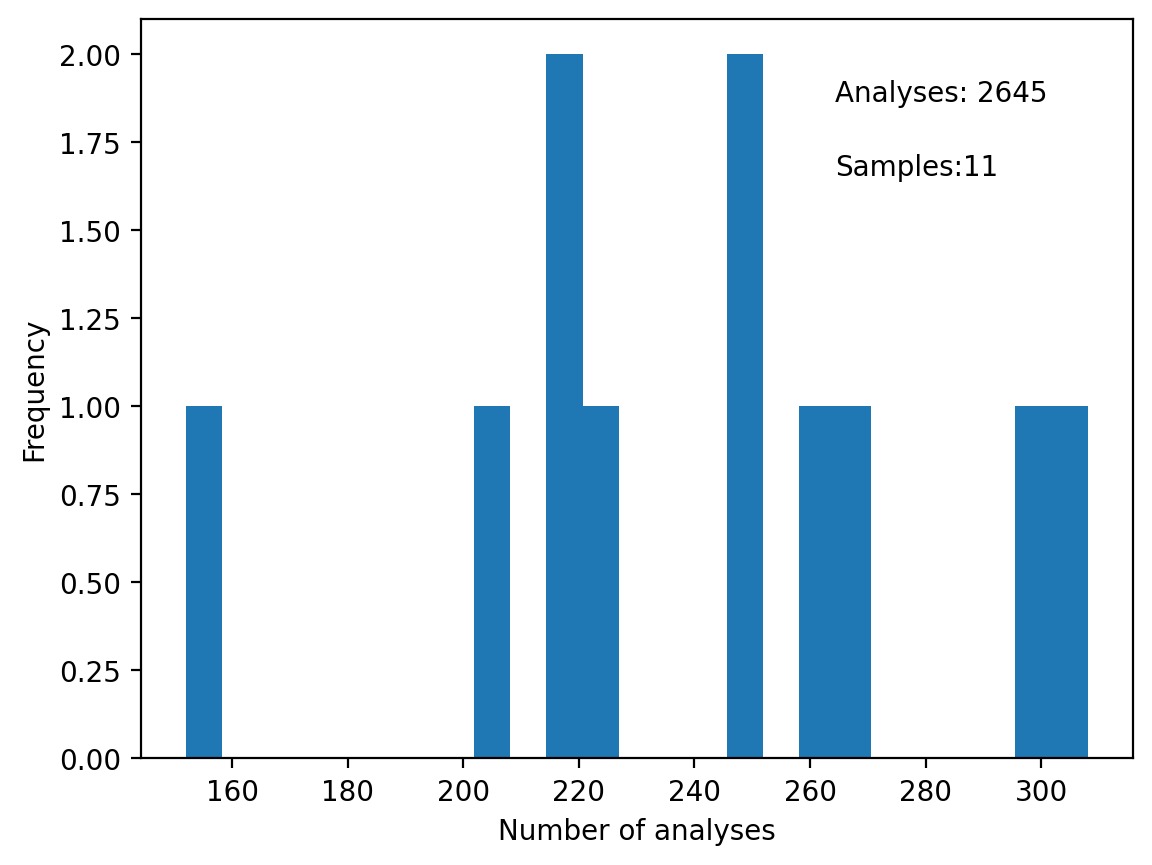

In [4]:
dFunc.plotSampleDist(main_byid_df, numBins=25)

### III. Select samples
Individual or groups of samples can be selected by entering their unique Sample ID's in an array or tuple. This sample list will be used for all subsequent plotting and analysis functions.

In [5]:
sampleList = ['CT-7','CT-5','CT-1','CT-6','CT-4','CT-10','CT-11','CT-8.2','CT-3','CT-2','CT-9',]
#sampleList = ['CT-1','CT-7', 'CT-3','CT-8.2','CT-9']

sigma = '2sigma' # Uncertainty level of U-Pb dates, options: '1sigma' or '2sigma'

ages, errors, numGrains, labels = dFunc.sampleToData(sampleList, main_byid_df, sigma=sigma);

## Plot detrital age distributions 0-25 Ma Bw = 2. 
Plot detrital age distributions as cumulative distribution functions (CDFs), probability density plots (PDPs), kernal density estimations (KDEs), histograms, and pie diagrams. Plotting options must be selected below.

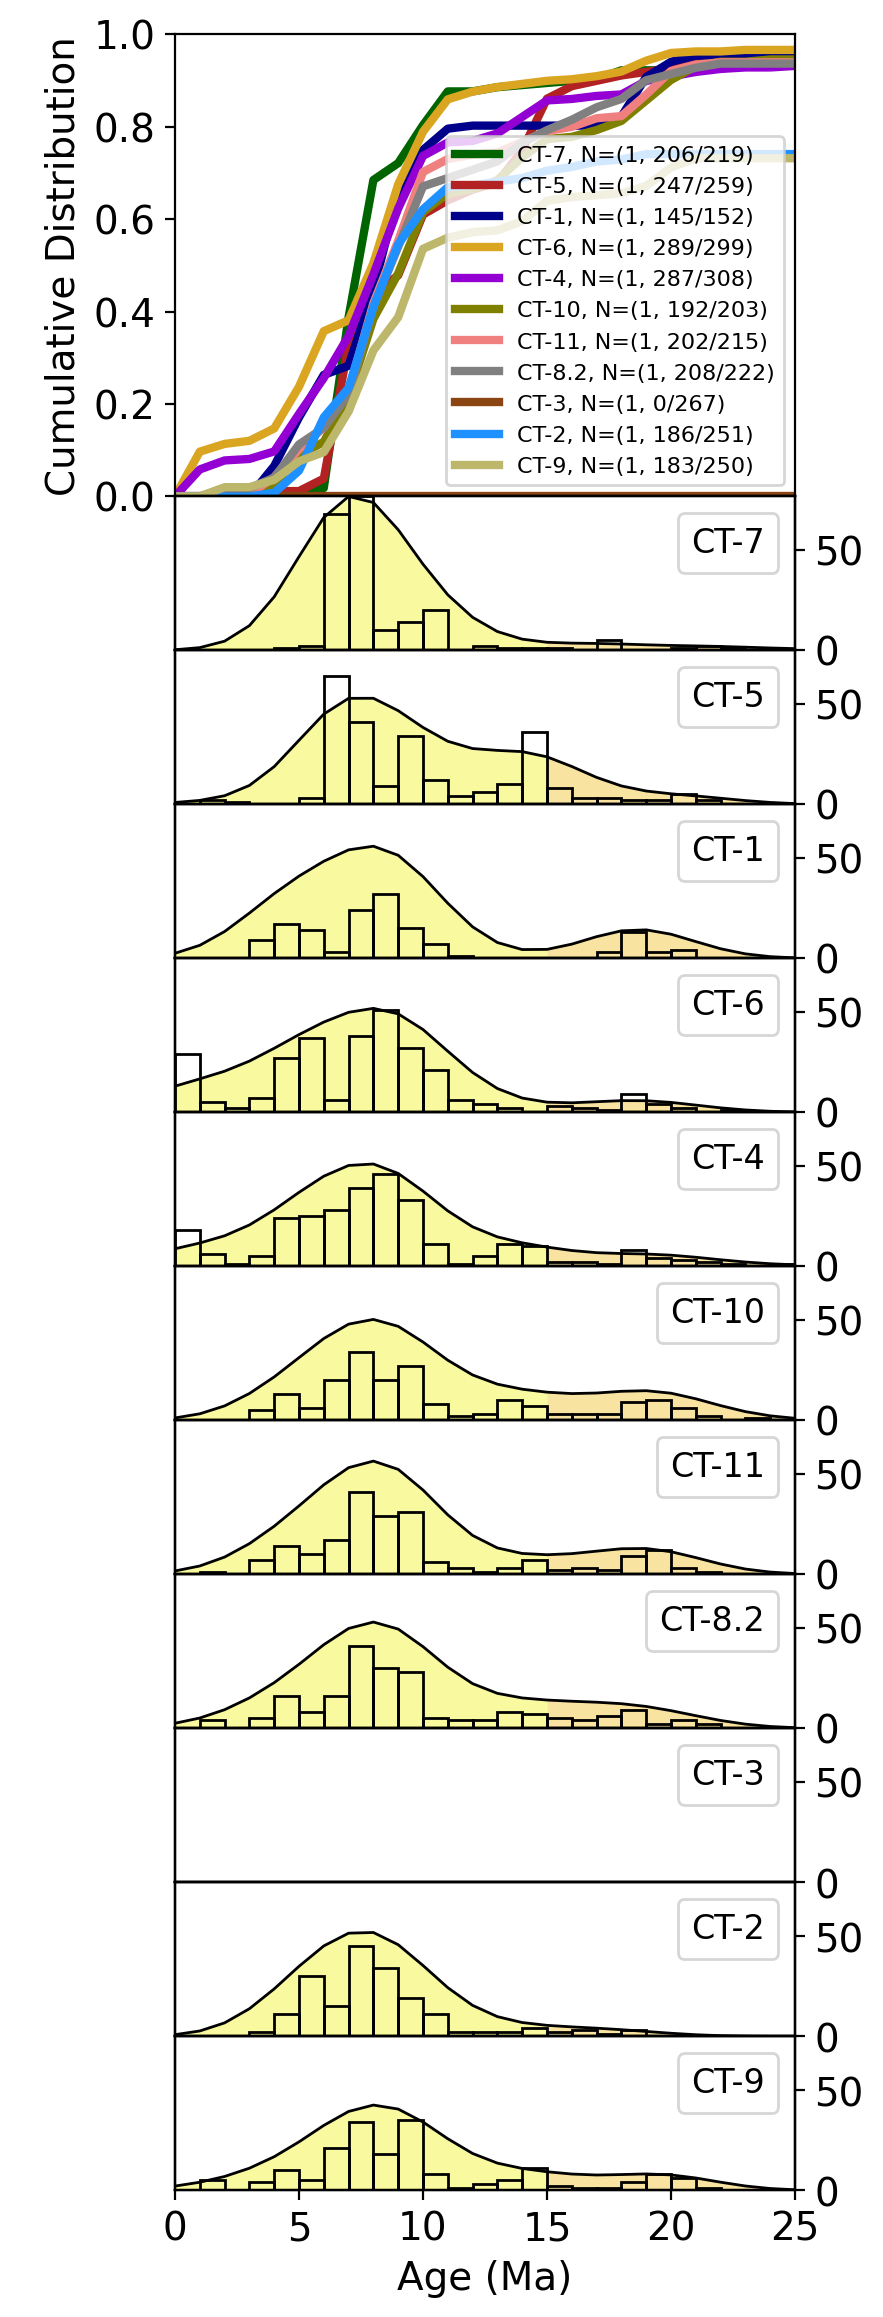

In [6]:
# Enter plot options below
whatToPlot = 'both' # Options: cumulative, relative, or both
separateSubplots = True # Set to True to plot each relative age distribution in a separate subplot (allows histogram and pie)

# Specify the age range (Myr) that you want to plot
x1 = 0
x2 = 25
plotLog = False # Set to True to plot the x-axis as a log scale

# Specify the plot dimensions
w = 5 # width of the plot
c = 3 # height of CDF panel
h = 5 # height of the relative panel (only required if separateSubplots is False). Options: 'auto' or an integer

# Specify the interval (Myr) over which distributions are calculated
xdif = 1 # Note: an interval of 1 Myr is recommended

# Cumulative distribution options
plotCDF = True # Plot the CDF discretized at xdif interval
plotCPDP = False # Plot the cumulative PDP
plotCKDE = False # Plot the cumulative KDE
plotDKW = False # Plot the 95% confidence interval of the CDF (Dvoretsky-Kiefer-Wolfowitz inequality)

# Relative distribution options
normPlots = True # Will normalize the PDP/KDE if equals True (if separateSubplots is True)

plotKDE = True # Set to True if want to plot KDE
colorKDE = False # Will color KDE according to same coloration as used in CDF plotting
colorKDEbyAge = True # Will color KDE according to age populations if set to True
bw = 2 # Specify the KDE bandwidth. Options are 'ISJ', 'optimizedFixed', 'optimizedVariable', or a number (bandwidth in Myr; e.g., bw = 3)
bw_x = None # X-axis location of bandwidth split (only used if multiple KDE values are specified in a list). Set to None if not using a split bandwidth.

plotPDP = False # Set to True if want to plot PDP
colorPDP = False # Will color PDP according to same coloration as used in CDF plotting
colorPDPbyAge = False # Will color PDP according to age populations if set to True

plotColorBar = False # Color age categories as vertical bars, can add white bars to create blank space between other colored bars

plotHist = True # Set to True to plot a histogram (only available when separateSubplots is True)
b = 1 # Specify the histogram bin size (Myr)

plotPIE = False # Will plot a pie diagram (only available when separateSubplots is True)

# Alternative way of specifying age bins
agebins = [[0,15],[15,30],[32,74],[82,119],[140,190],[200,252],[252,284],[284,320],[320,385],[385,440],[440,505],[505,550]]
agebinsc = [
    '#f5f542',  # yellow-green 
    '#f5c842',  # golden yellow 
    '#e8893a',  # muted orange 
    '#8db84a',  # muted yellow-green 
    '#3a8fc7',  # muted blue 
    '#7ab0d4',  # mid blue 
    '#d47a6e',  # muted salmon 
    '#d47a9a',  # muted pink 
    '#b89a8a',  # warm grey-brown 
    '#c8b89a',  # warm tan 
    '#a08060',  # mid tan 
    '#6e7840',  # muted olive 
]

plotAgePeaks = False # Will identify and plot age peaks
agePeakOptions = ['KDE', 0.05, 5, 2, True] # [distType, threshold, minDist, minPeakSize, labels]

# Plot PDP or KDE distributions as a heat map
plotHeatMap = False
heatMapType = 'KDE' # Options: 'PDP' or 'KDE'
heatMap = 'inferno_r'

fig = dFunc.plotAll(sampleList, ages, errors, numGrains, labels, whatToPlot, separateSubplots, plotCDF, plotCPDP, plotCKDE, 
                    plotDKW, normPlots, plotKDE, colorKDE, colorKDEbyAge, plotPDP, colorPDP, colorPDPbyAge, plotColorBar, 
                    plotHist, plotLog, plotPIE, x1, x2, b, bw, xdif, agebins, agebinsc, w, c, h, plotAgePeaks, agePeakOptions,
                    CDFlw=3, KDElw=1, PDPlw=1, bw_x=bw_x, plotHeatMap=plotHeatMap, heatMapType=heatMapType, heatMap=heatMap,
                    agebinsc_alpha = 0.5)

# Debug check: replicate detritalFuncs.py's KDE_bw_selector dispatch logic exactly,
# so this prints whatever bw actually resolves to for this cell's setting.

# Wrap the real functions so a call prints which one fired, then still runs normally
_real_sskernel = akde.sskernel
_real_ssvkernel = akde.ssvkernel

def sskernel_traced(*args, **kwargs):
    print(">>> akde.sskernel was called (FIXED, single bandwidth)")
    return _real_sskernel(*args, **kwargs)

def ssvkernel_traced(*args, **kwargs):
    print(">>> akde.ssvkernel was called (VARIABLE, array of bandwidths)")
    return _real_ssvkernel(*args, **kwargs)

akde.sskernel = sskernel_traced
akde.ssvkernel = ssvkernel_traced

# Now call the actual production function your plotAll cell uses
KDE_age_check, KDE_check = dFunc.KDEcalcAges(ages=[ages[0]], x1=x1, x2=x2, xdif=xdif, bw=bw)

# Restore the originals so plotAll's real run downstream isn't left wrapped
akde.sskernel = _real_sskernel
akde.ssvkernel = _real_ssvkernel

In [7]:
# Saves figure to a folder named 'Figures'
try:
    os.makedirs(ZIRCON_FIG_DIR, exist_ok=True)
    # Change name to current mixture and file type as a pdf, png, jpeg, svg, etc
    fig.savefig(os.path.join(ZIRCON_FIG_DIR, 'DZageDistributions0-25Ma.pdf'))
    print("Figures Created")
except Exception as e:
    print(f"Error saving figures: {e}")

Figures Created


## Plot detrital age distributions 0-400 Ma Bw = 2. 
Plot detrital age distributions as cumulative distribution functions (CDFs), probability density plots (PDPs), kernal density estimations (KDEs), histograms, and pie diagrams. Plotting options must be selected below.

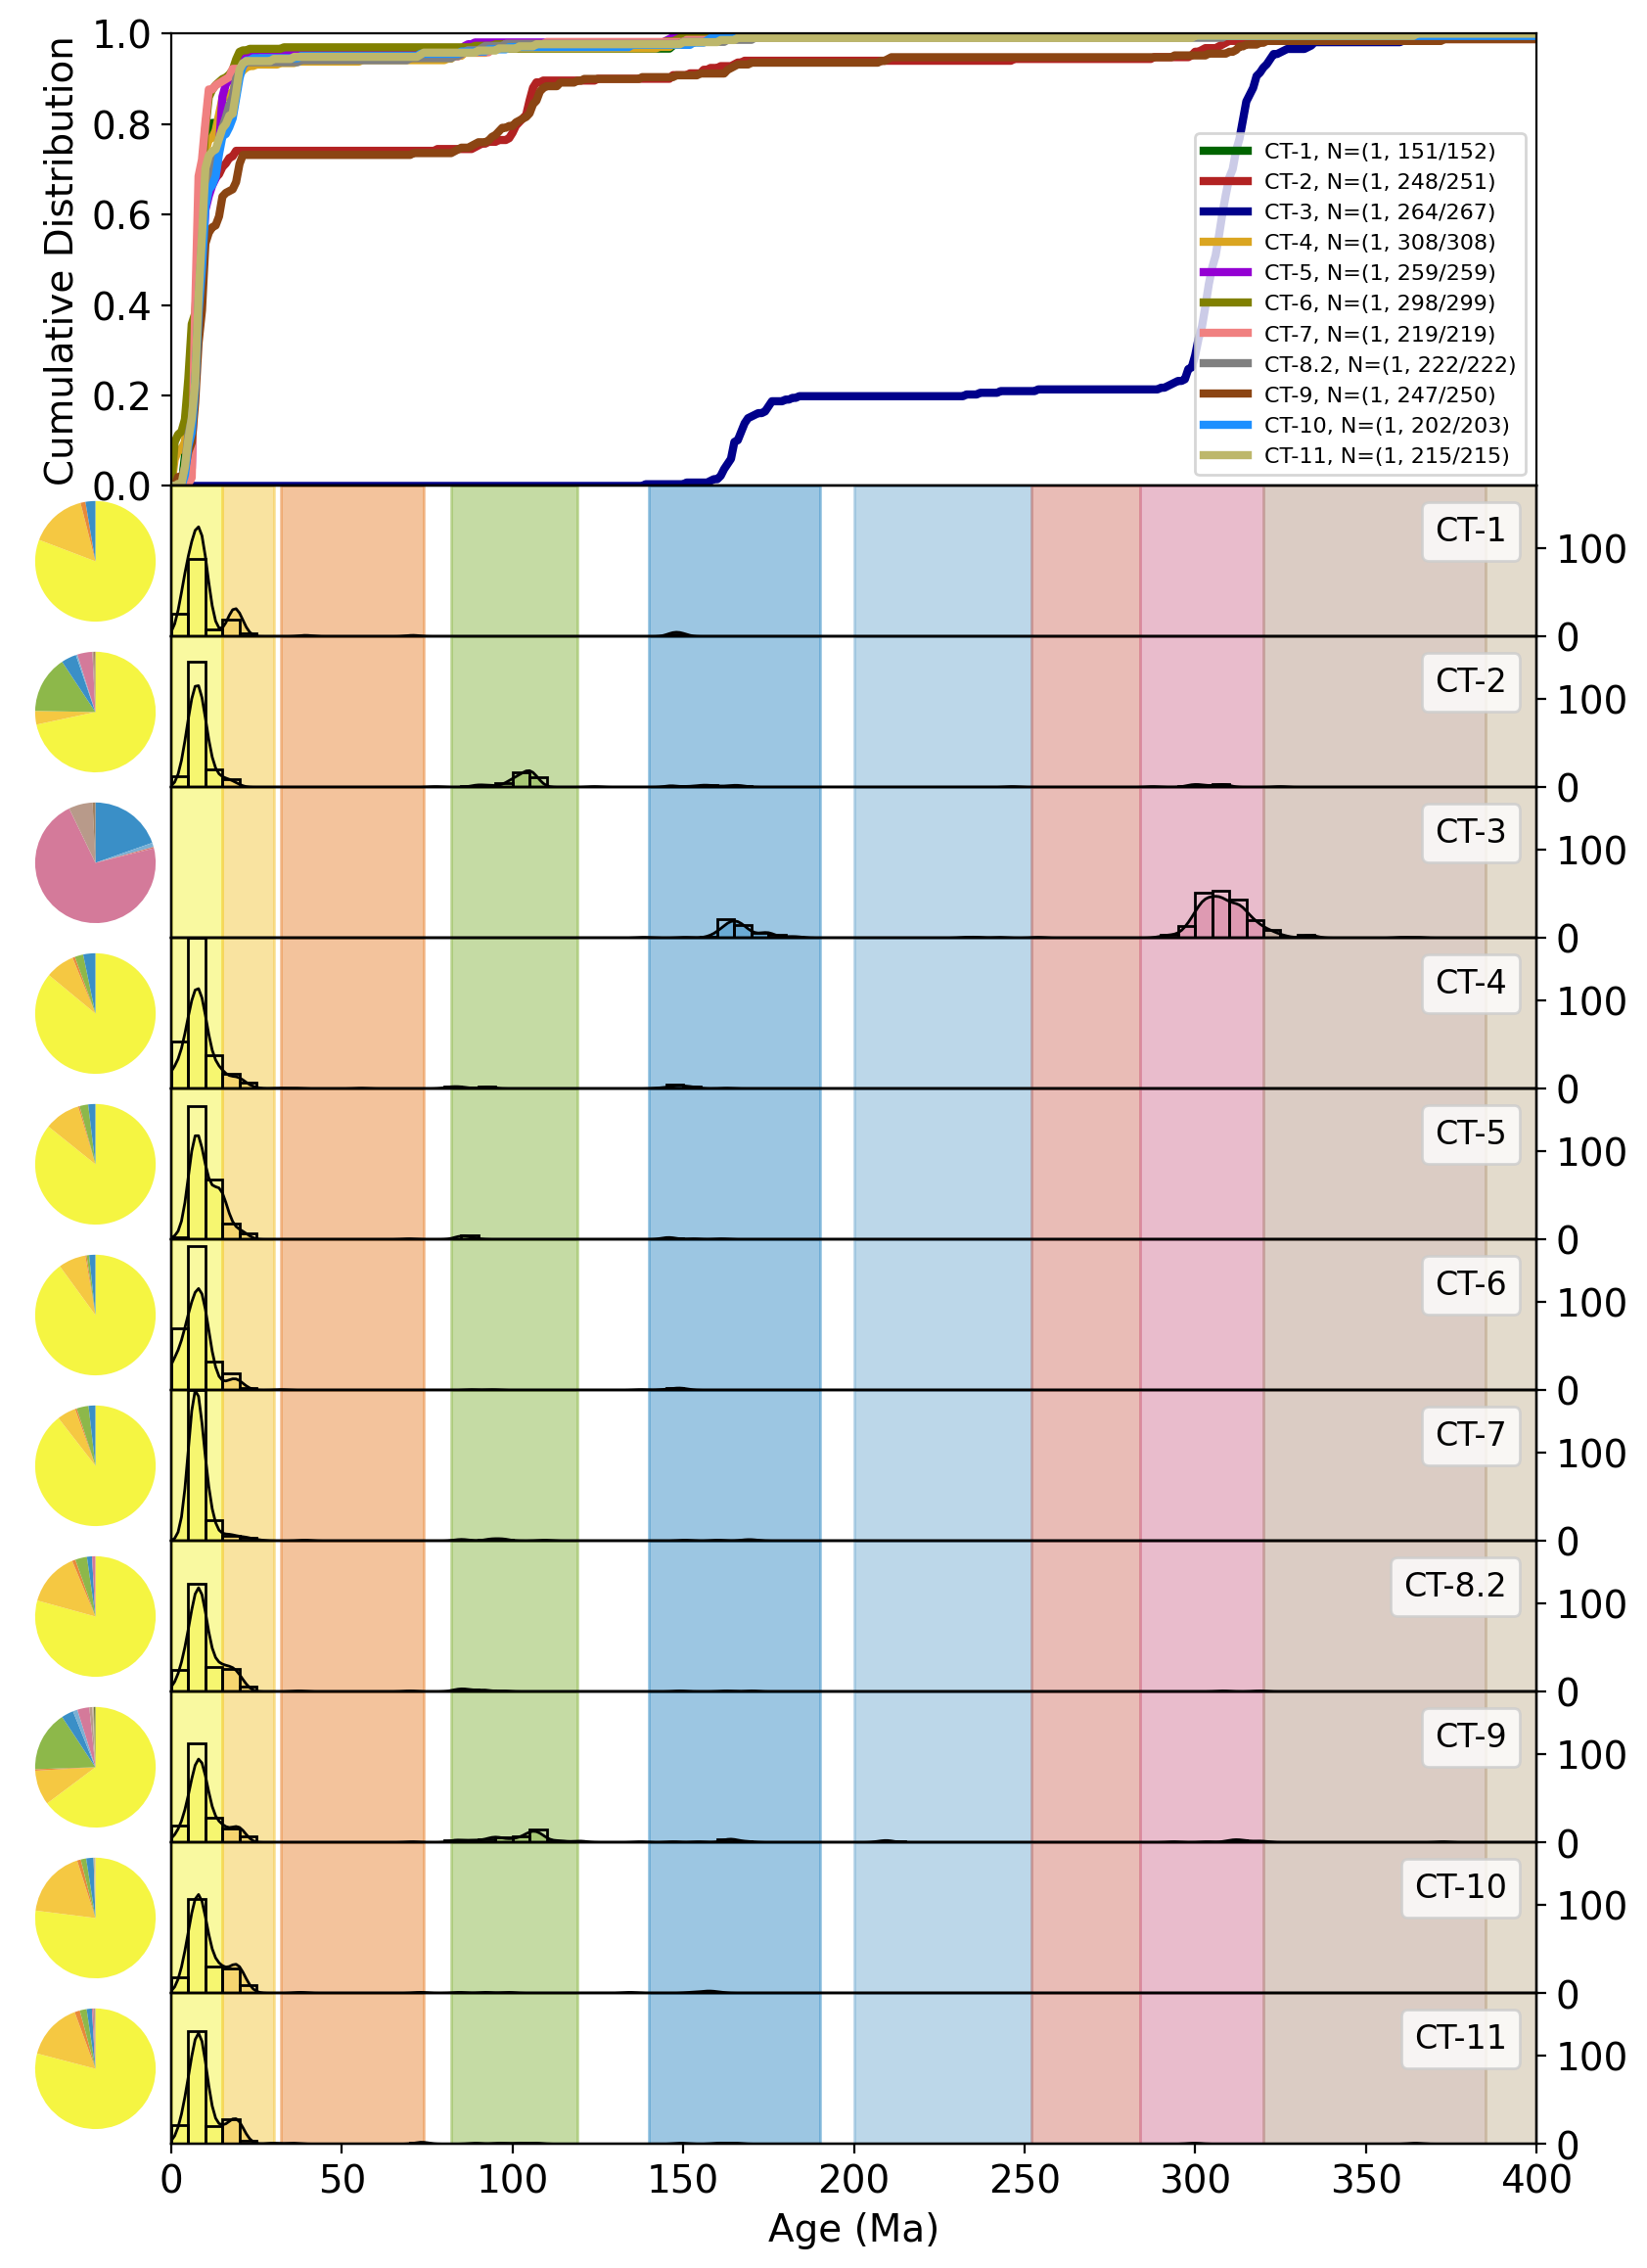

In [36]:
# Enter plot options below
whatToPlot = 'both' # Options: cumulative, relative, or both
separateSubplots = True # Set to True to plot each relative age distribution in a separate subplot (allows histogram and pie)

# Specify the age range (Myr) that you want to plot
x1 = 0
x2 = 400
plotLog = False # Set to True to plot the x-axis as a log scale

# Specify the plot dimensions
w = 10 # width of the plot
c = 3 # height of CDF panel
h = 5 # height of the relative panel (only required if separateSubplots is False). Options: 'auto' or an integer

# Specify the interval (Myr) over which distributions are calculated
xdif = 1 # Note: an interval of 1 Myr is recommended

# Cumulative distribution options
plotCDF = True # Plot the CDF discretized at xdif interval
plotCPDP = False # Plot the cumulative PDP
plotCKDE = False # Plot the cumulative KDE
plotDKW = False # Plot the 95% confidence interval of the CDF (Dvoretsky-Kiefer-Wolfowitz inequality)

# Relative distribution options
normPlots = True # Will normalize the PDP/KDE if equals True (if separateSubplots is True)

plotKDE = True # Set to True if want to plot KDE
colorKDE = False # Will color KDE according to same coloration as used in CDF plotting
colorKDEbyAge = True # Will color KDE according to age populations if set to True
bw = 2 # Specify the KDE bandwidth. Options are 'ISJ', 'optimizedFixed', 'optimizedVariable', or a number (bandwidth in Myr; e.g., bw = 3)
bw_x = None # X-axis location of bandwidth split (only used if multiple KDE values are specified in a list). Set to None if not using a split bandwidth.

plotPDP = False # Set to True if want to plot PDP
colorPDP = False # Will color PDP according to same coloration as used in CDF plotting
colorPDPbyAge = False # Will color PDP according to age populations if set to True

plotColorBar = True # Color age categories as vertical bars, can add white bars to create blank space between other colored bars

plotHist = True # Set to True to plot a histogram (only available when separateSubplots is True)
b = 5 # Specify the histogram bin size (Myr)

plotPIE = True # Will plot a pie diagram (only available when separateSubplots is True)

# Alternative way of specifying age bins
agebins = [[0,15],[15,30],[32,74],[82,119],[140,190],[200,252],[252,284],[284,320],[320,385],[385,440],[440,505],[505,550]]
agebinsc = [
    '#f5f542',  # yellow-green 
    '#f5c842',  # golden yellow 
    '#e8893a',  # muted orange 
    '#8db84a',  # muted yellow-green 
    '#3a8fc7',  # muted blue 
    '#7ab0d4',  # mid blue 
    '#d47a6e',  # muted salmon 
    '#d47a9a',  # muted pink 
    '#b89a8a',  # warm grey-brown 
    '#c8b89a',  # warm tan 
    '#a08060',  # mid tan 
    '#6e7840',  # muted olive 
]

plotAgePeaks = False # Will identify and plot age peaks
agePeakOptions = ['KDE', 0.05, 5, 2, True] # [distType, threshold, minDist, minPeakSize, labels]

# Plot PDP or KDE distributions as a heat map
plotHeatMap = False
heatMapType = 'KDE' # Options: 'PDP' or 'KDE'
heatMap = 'inferno_r'

fig = dFunc.plotAll(sampleList, ages, errors, numGrains, labels, whatToPlot, separateSubplots, plotCDF, plotCPDP, plotCKDE, 
                    plotDKW, normPlots, plotKDE, colorKDE, colorKDEbyAge, plotPDP, colorPDP, colorPDPbyAge, plotColorBar, 
                    plotHist, plotLog, plotPIE, x1, x2, b, bw, xdif, agebins, agebinsc, w, c, h, plotAgePeaks, agePeakOptions,
                    CDFlw=3, KDElw=1, PDPlw=1, bw_x=bw_x, plotHeatMap=plotHeatMap, heatMapType=heatMapType, heatMap=heatMap,
                    agebinsc_alpha = 0.5)

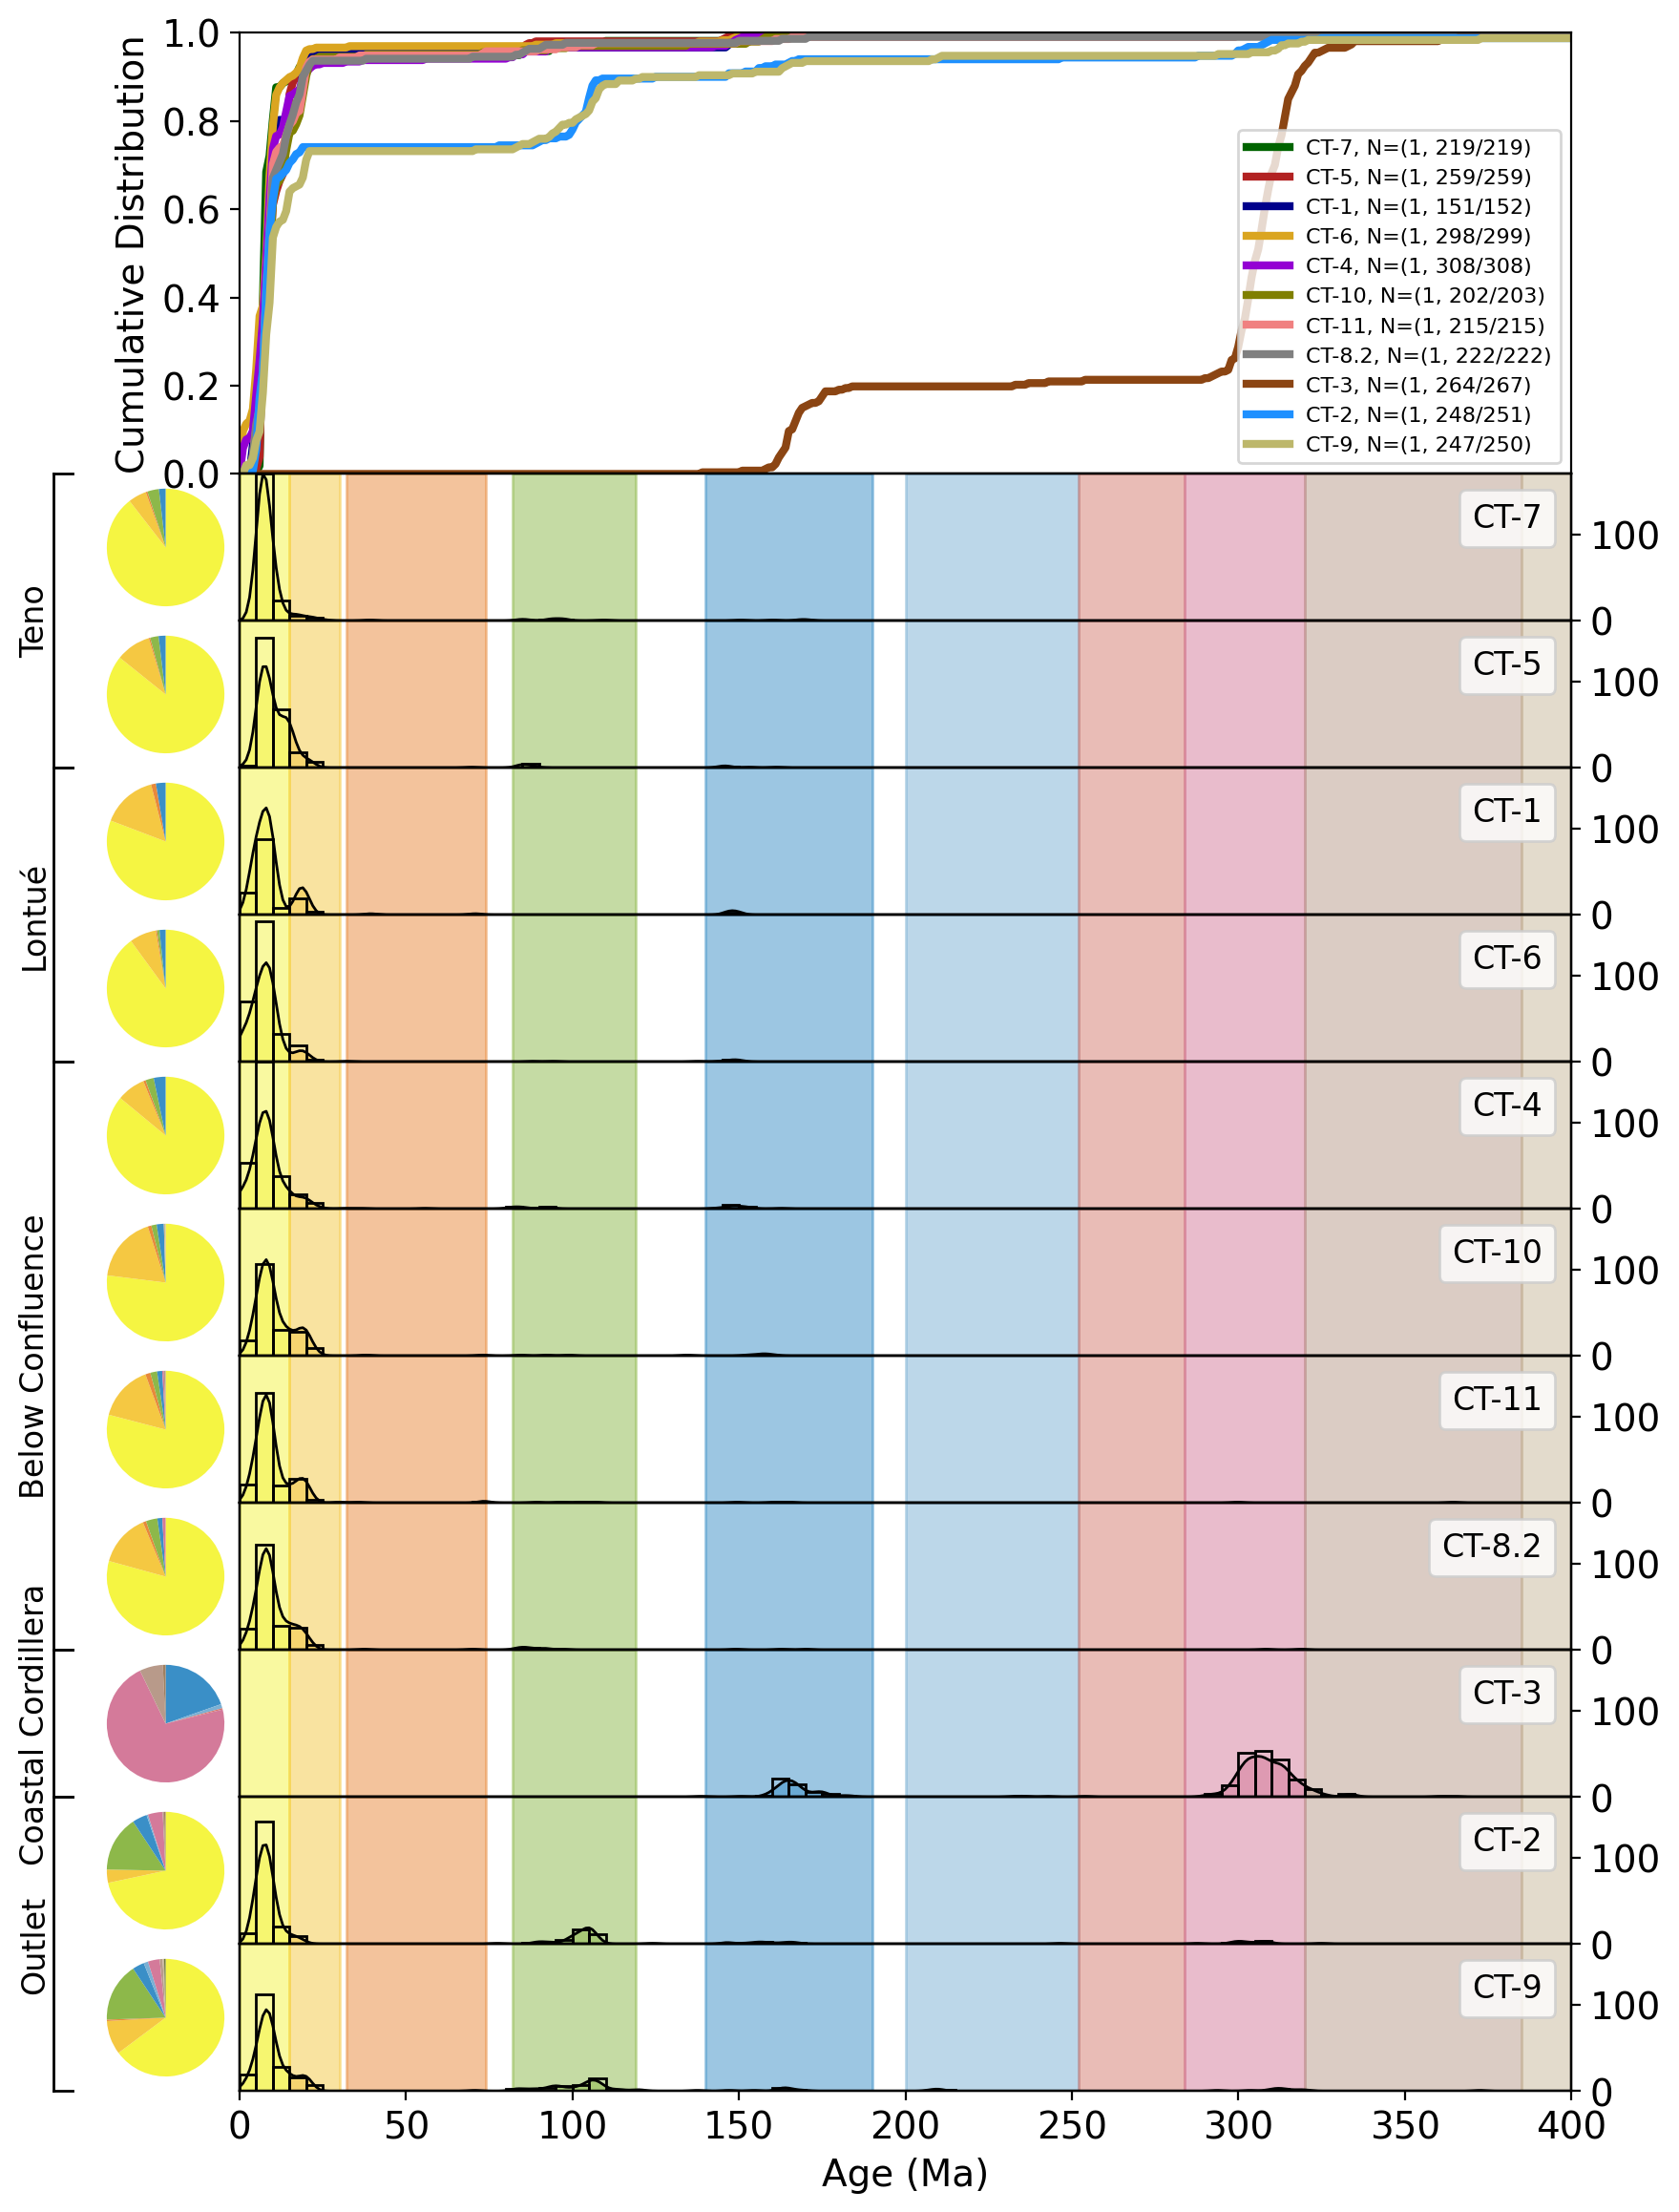

In [9]:
import matplotlib.patches as patches
from matplotlib.lines import Line2D

# Find each sample's pie chart subplot, sorted top to bottom
pie_axes = [ax for ax in fig.axes if any(isinstance(p, patches.Wedge) for p in ax.patches)]
pie_axes.sort(key=lambda ax: ax.get_position().y0, reverse=True)

# Get the real top/bottom of each sample's row, and the left edge of the pie column
sample_bounds = [(ax.get_position().y0, ax.get_position().y1) for ax in pie_axes]
x_pos = min(ax.get_position().x0 for ax in pie_axes) - 0.02  # just left of the pies

def add_group_bracket(fig, y_top, y_bottom, label, x):
    fig.add_artist(Line2D([x, x], [y_bottom, y_top], transform=fig.transFigure, color='black', lw=1))
    fig.add_artist(Line2D([x, x+0.01], [y_top, y_top], transform=fig.transFigure, color='black', lw=1))
    fig.add_artist(Line2D([x, x+0.01], [y_bottom, y_bottom], transform=fig.transFigure, color='black', lw=1))
    fig.text(x-0.01, (y_top+y_bottom)/2, label, rotation=90, ha='center', va='center', fontsize=12)

groups = [
    ('Teno', 2),
    ('Lontué', 2),
    ('Below Confluence', 4),
    ('Coastal Cordillera', 1),
    ('Outlet', 2),
]

y = 0
for label, n in groups:
    rows = sample_bounds[y:y+n]
    y_top = max(r[1] for r in rows)
    y_bottom = min(r[0] for r in rows)
    add_group_bracket(fig, y_top=y_top, y_bottom=y_bottom, label=label, x=x_pos)
    y += n

fig

Optional: Run the cell below to save the figure as a pdf file

In [10]:
# Saves figure to a folder named 'Figures'
try:
    os.makedirs(ZIRCON_FIG_DIR, exist_ok=True)
    # Change name to current mixture and save figure as a pdf, png, jpeg, svg, etc
    fig.savefig(os.path.join(ZIRCON_FIG_DIR, 'DZageDistributions0-400Ma.pdf'))
    print("Figures Created")
except Exception as e:
    print(f"Error saving figures: {e}")

Figures Created


### Plot detrital age populations as a bar graph

In [11]:
sampleList = ['CT-1','CT-2','CT-3','CT-4','CT-5','CT-6','CT-7','CT-8.2','CT-9','CT-10','CT-11']

ages, errors, numGrains, labels = dFunc.sampleToData(sampleList, main_byid_df, sigma = '1sigma');

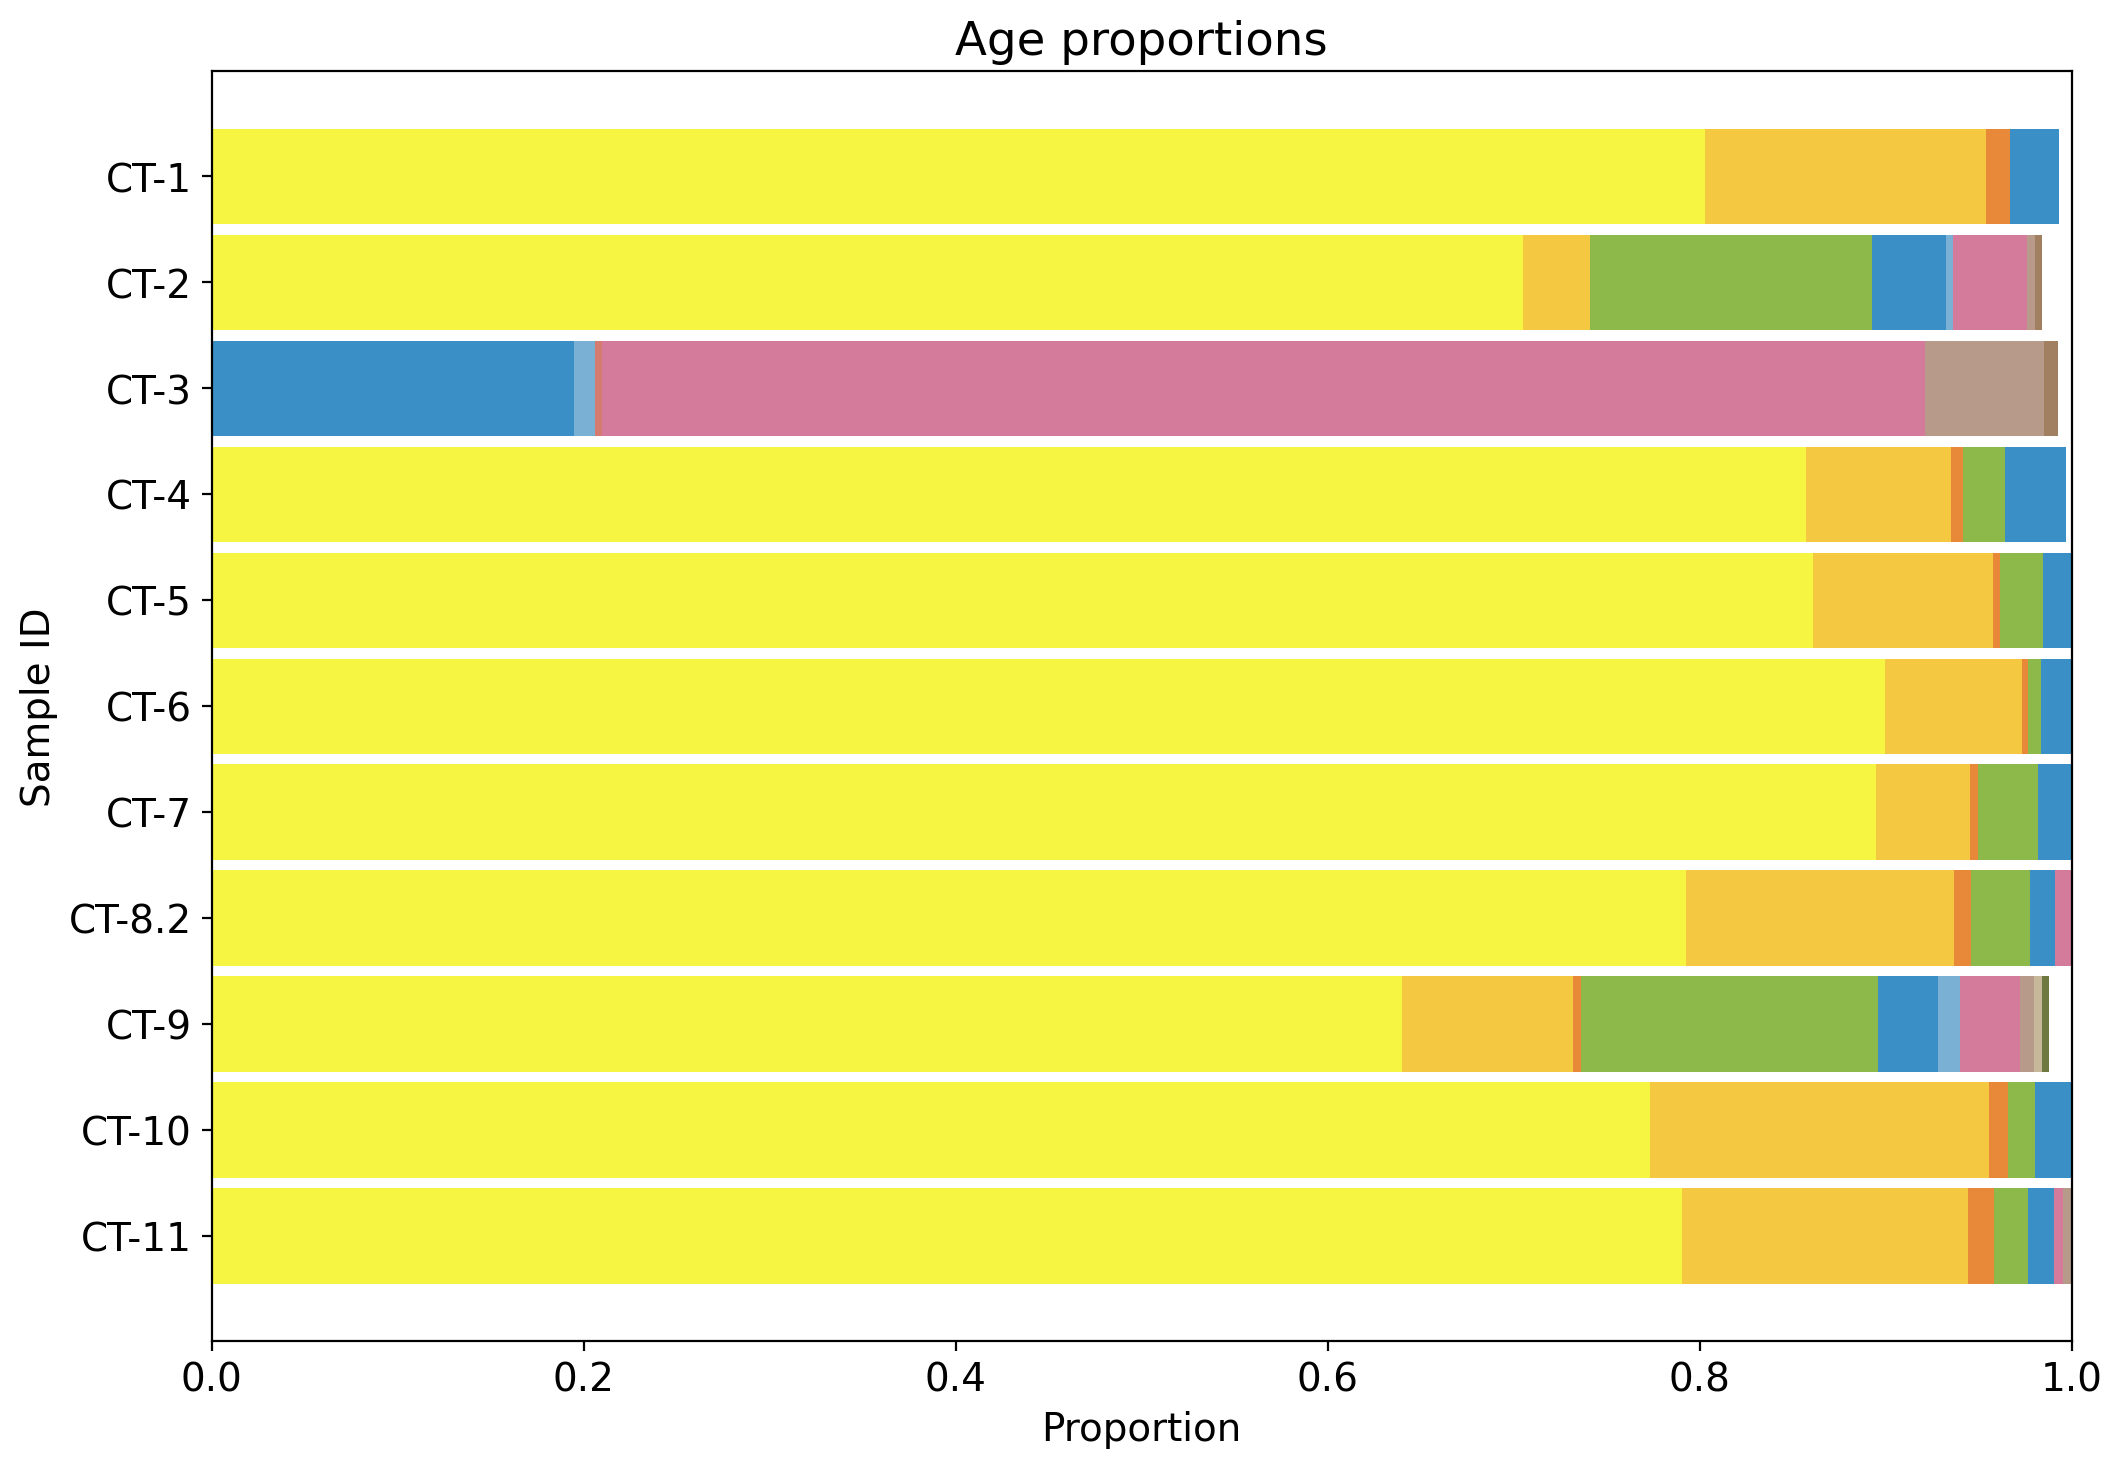

In [13]:
# Specify plot parameters
overlap = 0.9
width = 6
height = 0.75

# Specify  age population boundaries and colors
# Alternative way of specifying age bins
agebins = [[0,15],[15,30],[32,74],[82,119],[140,190],[200,252],[252,284],[284,320],[320,385],[385,440],[440,505],[505,550]]
agebinsc = [
    '#f5f542',  # yellow-green (was #f0ffa8, too pale)
    '#f5c842',  # golden yellow (was #ffe26e, slightly richer)
    '#e8893a',  # muted orange (was orange, toned down)
    '#8db84a',  # muted yellow-green (was yellowgreen, toned down)
    '#3a8fc7',  # muted blue (was #17a8ff, toned down)
    '#7ab0d4',  # mid blue (was #cee2ff, richened)
    '#d47a6e',  # muted salmon (was salmon, slightly richer)
    '#d47a9a',  # muted pink (was pink, richened)
    '#b89a8a',  # warm grey-brown (was #f0e2e2, richened)
    '#c8b89a',  # warm tan (was white, replaced with substance)
    '#a08060',  # mid tan (was tan, richened)
    '#6e7840',  # muted olive (was olive, consistent)
]

# Specify whether to separate grouped sample lists into individual samples
separateGroups = True # Set to True to separate groups into their individual samples

fileName = 'ageProportionsCT-1-11.csv' # Specify file name to save

savePlot = False #Specify whether to save output plots as PDF files

dFunc.ageProportionsCSV(ages, errors, numGrains, labels, agebins, fileName)
figBar = dFunc.plotBar(width, height, overlap, main_byid_df, sampleList, ages, numGrains, labels, agebins, agebinsc, separateGroups, savePlot)

## Plot sample locations on an interactive map
Samples with coordinate information (latitude and longitude in WGS84 coordinates) can be plotted on an interactive map. This functionality requires the following modules must be installed: folium and vincent. These can be installed via the python command line prompt by entering "pip install folium" and "pip install vincent".

In [14]:
# Specify whether age distributions should be enabled (can be viewed by clicking on samples)
plotMapKDE = True # Choose True to enable KDEs when samples are selected
plotMapPDP = False # Choose True to enable PDPs when samples are selected
plotCumulative = False # Choose True to plot either a cumulative KDE or PDP. A discretized CDF will be plotted if KDE and PDP are both set to False

# Specify the upper age limit that you want to plot
x2 = 400
# Specify the KDE bandwidth
bw = 2 # Specify the KDE bandwidth. Options are 'optimizedFixed', 'optimizedVariable', or a number (bandwidth in Myr)

mapType = 'World_Topo_Map' # Options: 'NatGeo_World_Map', 'World_Street_Map', 'World_Topo_Map', 'World_Light_Gray',
                             # 'World_Shaded_Relief', 'World_Terrain_Base', 'World_Hillshade', 'World_Physical_Map'

exportKML = True
descrpt = 'Unit' # Description to be included with each sample
    
dFunc.plotFoliumMap(sampleList, main_byid_df, ages, errors, numGrains, plotMapKDE, 
                             plotMapPDP, plotCumulative, x2, bw, mapType, exportKML, descrpt)

0.2972249999999974
1.2735800000000097
latitude 0.2972249999999974 -> (0.5, 9)
longitude 1.2735800000000097 -> (2.5, 7)


## Plot and export maximum depositional age (MDA) calculations
Take it out of comment if you are using MDA

Calculate the maxmium depositional age (MDA) for a sample or group of samples. Results will be exported to a CSV file. Individual plots will be made for each sample or group of samples showing the youngest grains and different calculations of the maxmimum depositional age.

# Specify output CSV file
fileName = 'MDA.csv'

# Specify whether to create a plot showing youngest ages and MDA calculations
makePlot = True

# Specify how grains are sorted on the plot: by best age, best age + 1 sigma error, or best age + 2 sigma error
sortBy = '1sigma' # Options: 'mean', '1sigma', '2sigma'

# Specify plot parameters
plotWidth = 8
plotHeight = 5
barWidth = 0.25 # A value of 1 yields 100% overlap
ageColors = ['blue','red','green'] # Specify color of horizontal bars for YSG, YC1S(2+), and YC2s(3+), respectively
fillMDACalcs = True # Select True to shade each MDA calculation within 1 sigma confidence limits
alpha = 0.25 # Specifies the transparency of the MDA calculation colors

figMDA = dFunc.MDAtoCSV(sampleList, ages, errors, numGrains, labels, fileName, sortBy, barWidth, plotWidth, plotHeight, 
                        ageColors, alpha, makePlot, fillMDACalcs)

Optional: Run the cell below to save the figure as an image file

pathlib.Path('Output').mkdir(parents=True, exist_ok=True) # Recursively creates the directory and does not raise an exception if the directory already exists 
figMDA.savefig('../results/detritalpy_output/MDAplots.png')

## Multi-dimensional scaling
Create a multi-dimensional scaling (MDS) plot for individual samples or groups of samples. Revised and updated in detritalpy v1.4.6, scikit-learn v1.7+ recommended.

In [15]:
import sklearn
print(sklearn.__version__) #scikit-learn v1.7+ recommended

1.9.0


In [16]:
sampleList = ['CT-1','CT-2','CT-3','CT-4','CT-5','CT-6','CT-7','CT-8.2','CT-9','CT-10','CT-11']

ages, errors, numGrains, labels = dFunc.sampleToData(sampleList, main_byid_df, sigma = '2sigma');

Run the model. Note that this may take a while, depending on the number of initializations (n_init) chosen. Increasing the number of initializations increased the likelihood of finding a more optimal fit (i.e., lower stress).

In [17]:
model = dFunc.MDS_class(ages, errors, labels, sampleList, metric=True, criteria='Vmax', bw=2, n_init=1000, 
                        max_iter=1000, x1=0, x2=4500, xdif=1, min_dim=1, max_dim=3, dim=2, normalized_stress=True)

/Users/Glong1/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/Glong1/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/Glong1/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
/Users/Glong1/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/Glong1/anaconda3/lib/python3.11/site-packages/sklearn/man

After the model has been run, a number of figures can be generated, in any order.

The QQ matrix plots each sample CDF against the others. A perfect match falls along the dashed line. <i>Note: This is not recommended for large datasets (e.g., >20 samples or sample groups)</i>

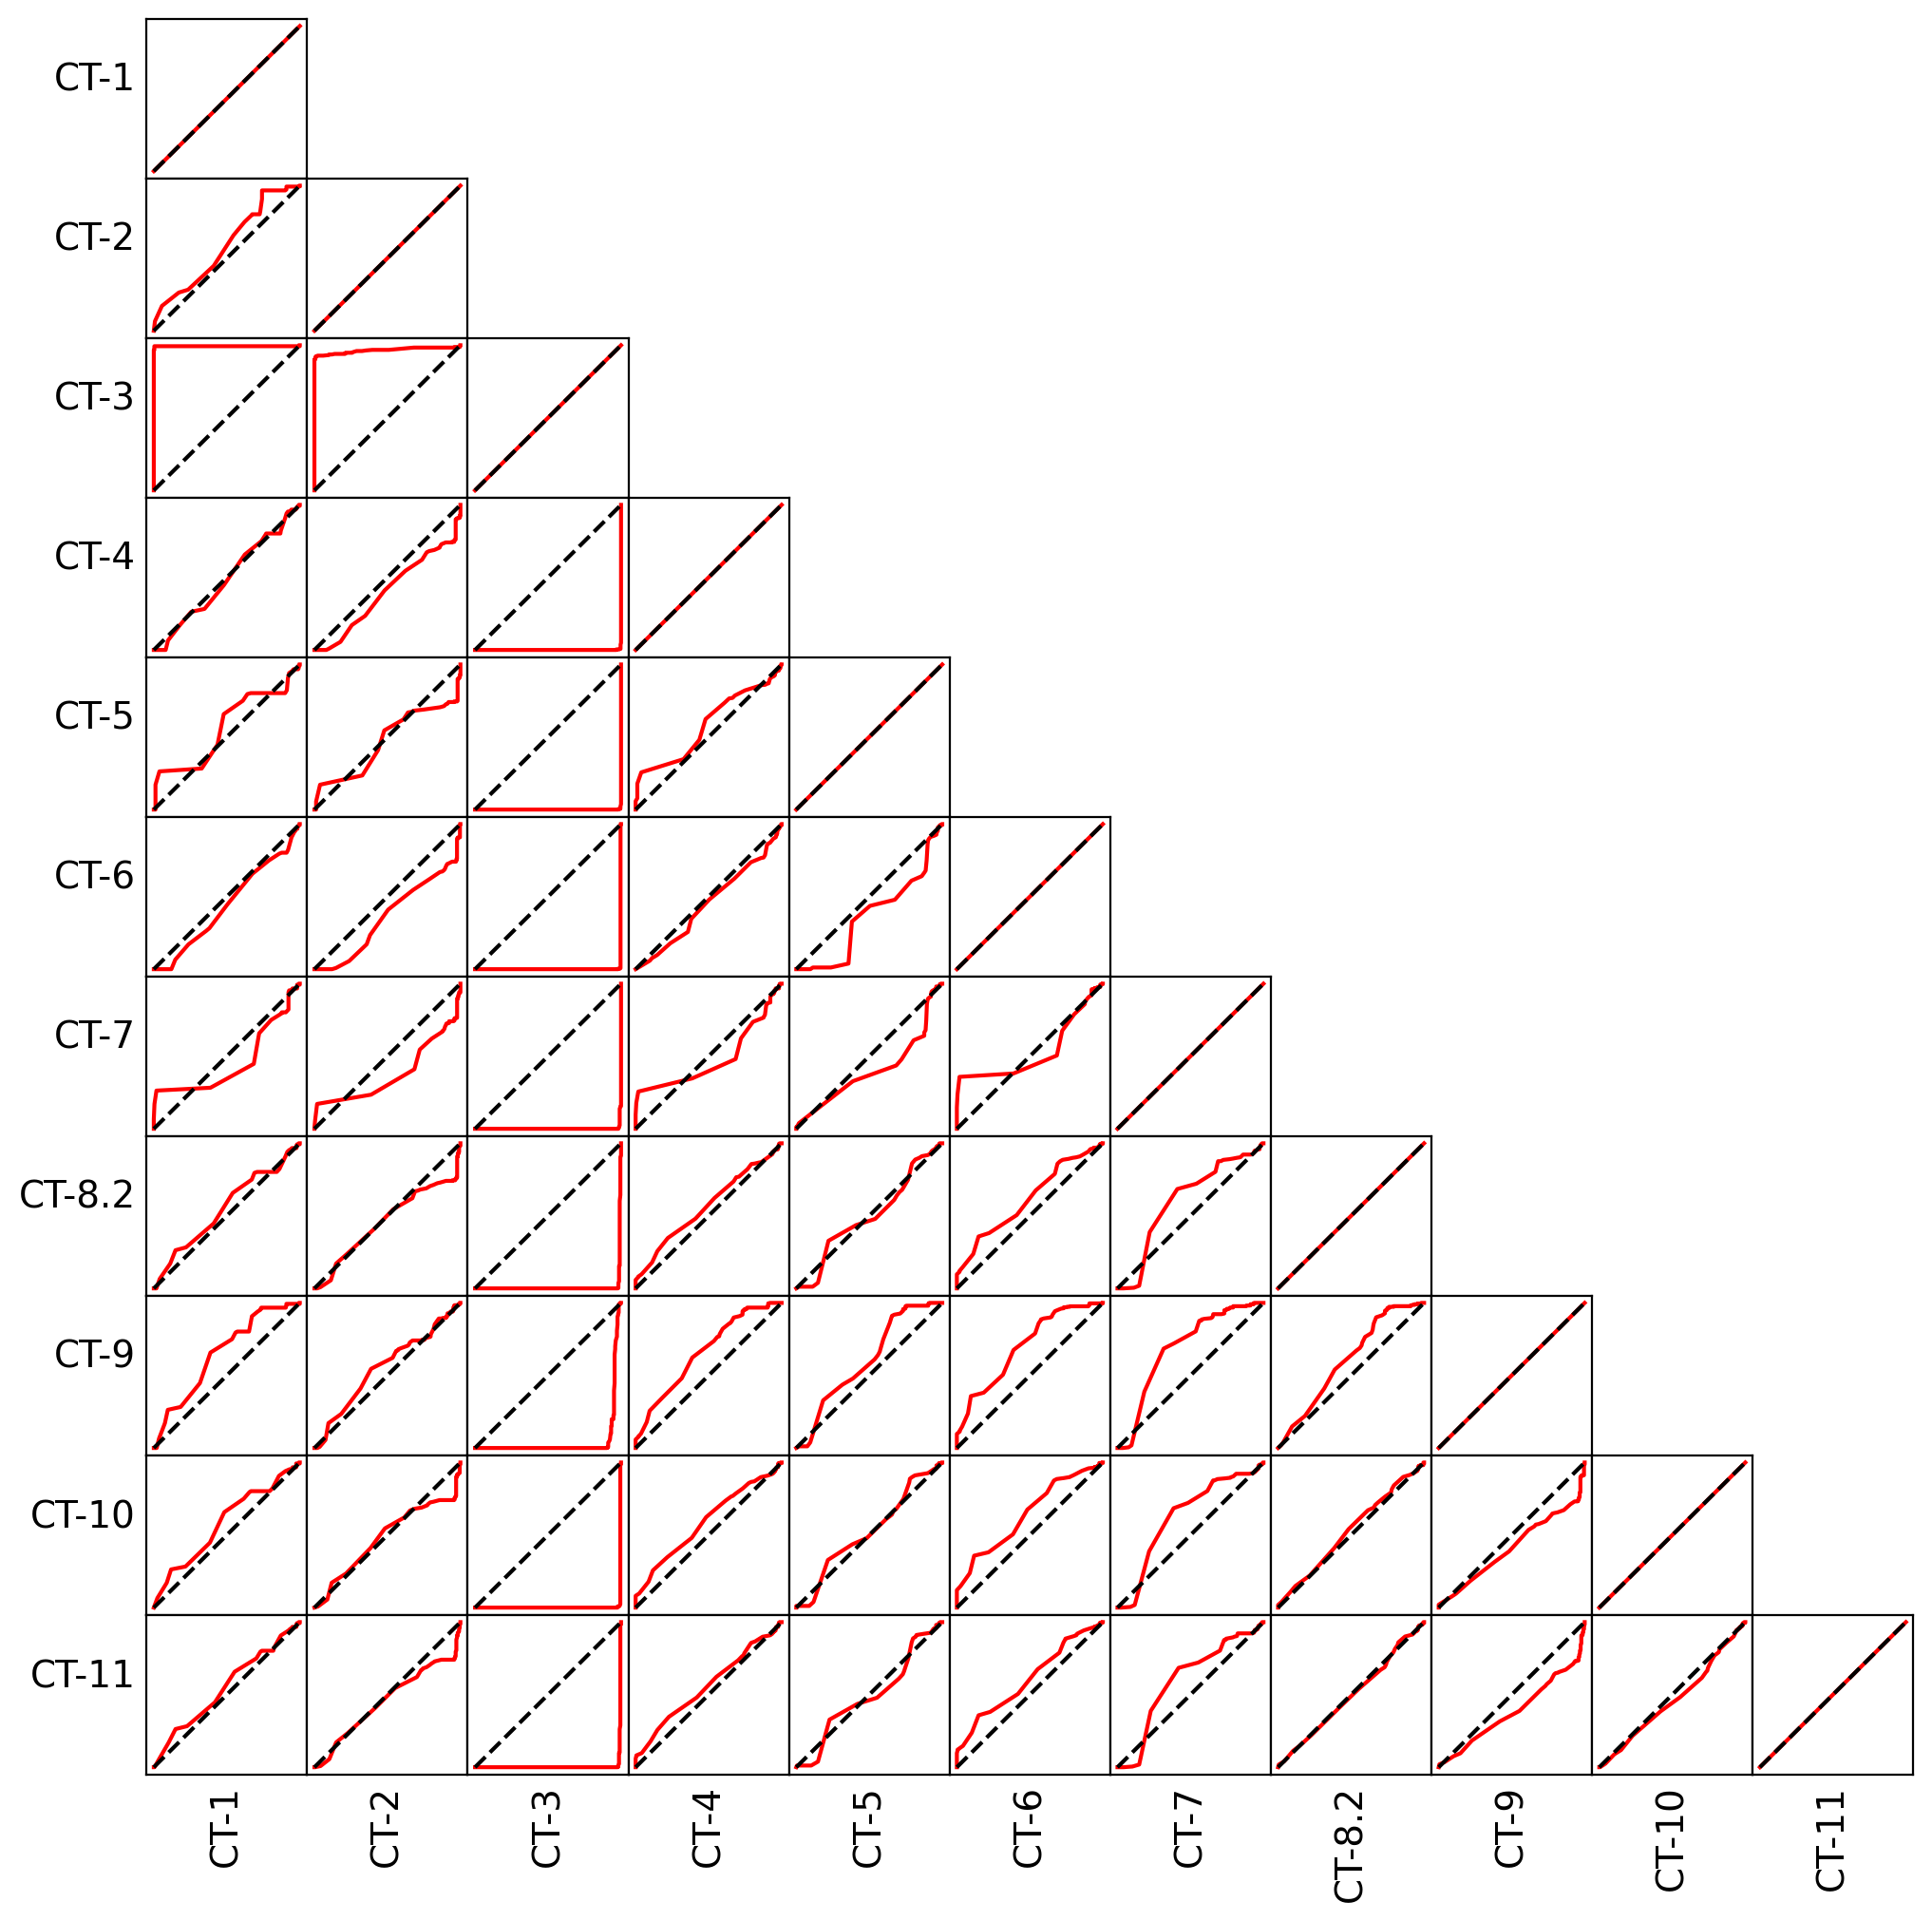

In [18]:
model.QQplot(figsize=(12,12), savePlot=False, fileName='QQplot.pdf', halfMatrix=True)

A heatmap of the sample dissimilarity matrix gives an indication of the data that is going into the MDS algorithm

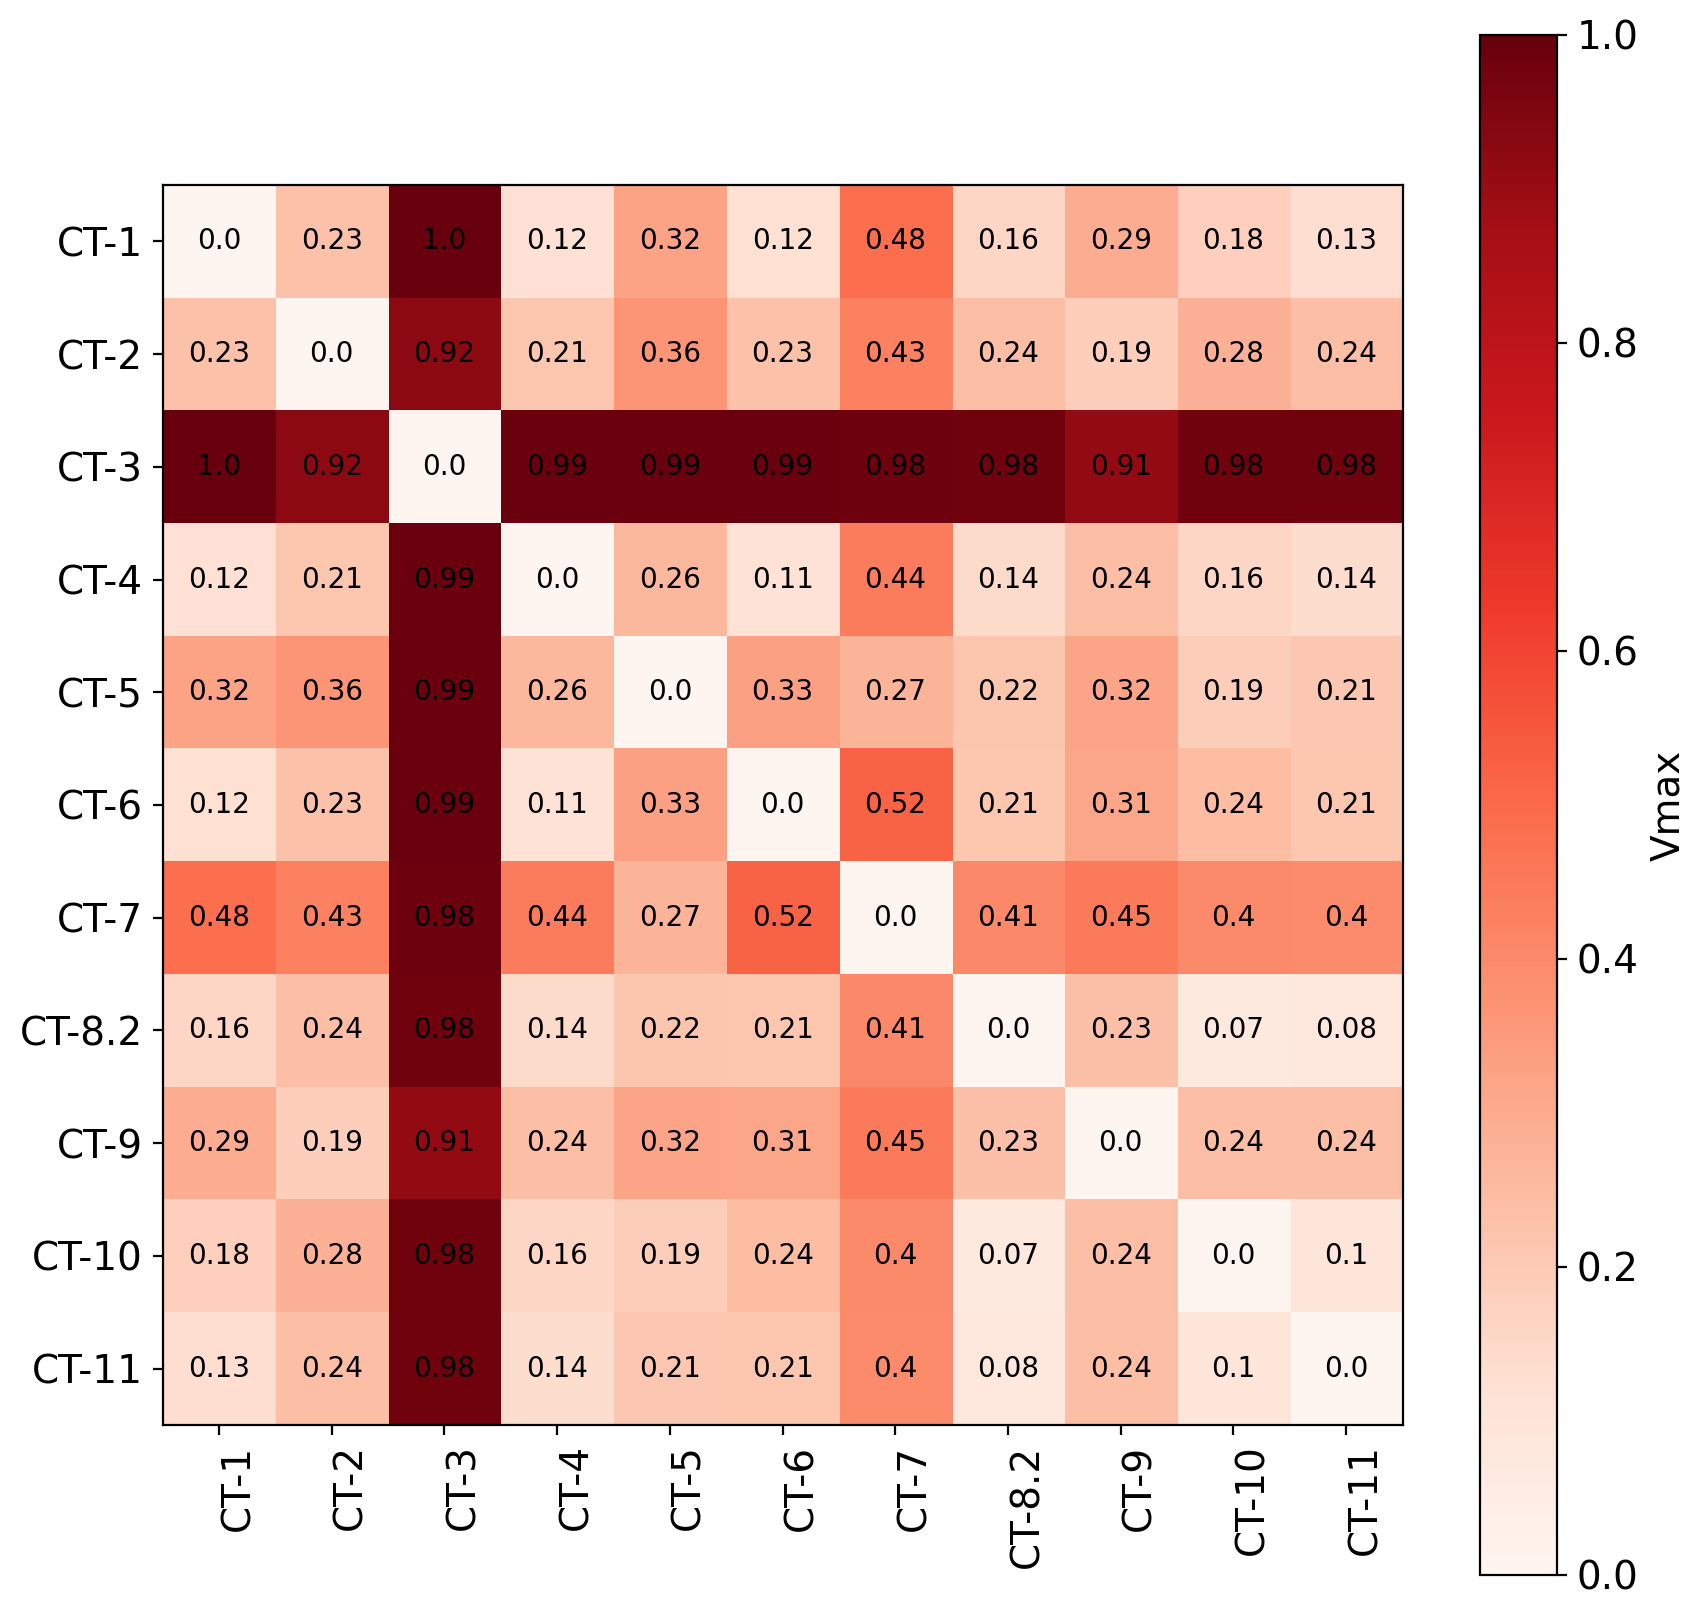

In [19]:
model.heatMap(figsize=(10,10), savePlot=False, fileName='HeatMapPlot.pdf', plotValues=True,
              plotType='dissimilarity', fontsize=10)

By setting the keyword argument plotType to equal 'distance', we can plot the Euclidean distance between sample pairs on the MDS plot. There should be a general correlation with the heat mat above, as samples that are more different should be farther apart.

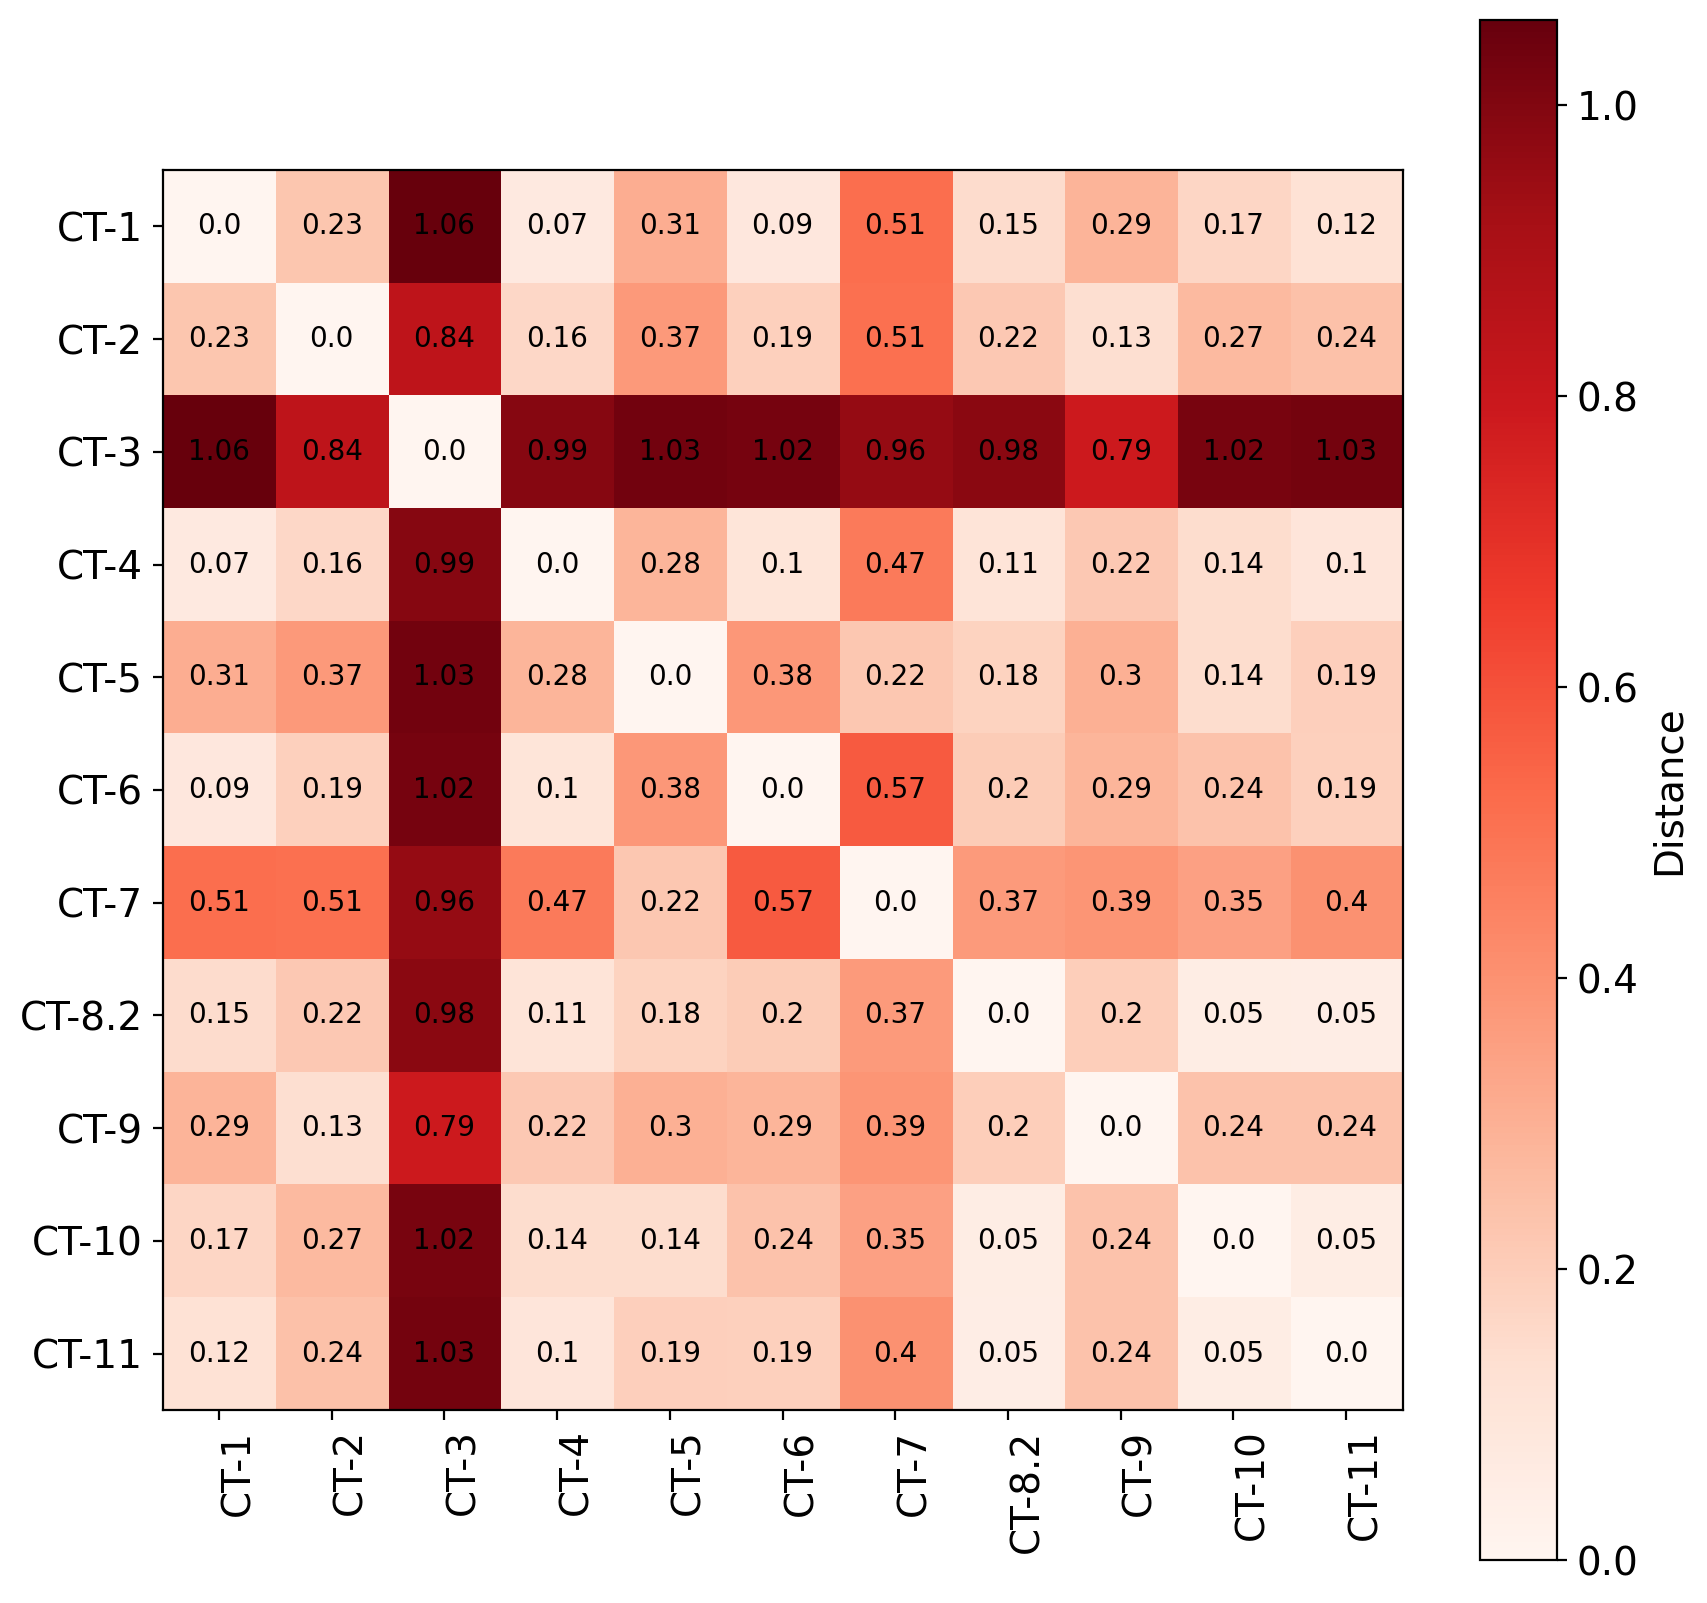

In [20]:
model.heatMap(figsize=(10,10), savePlot=False, fileName='HeatMapPlot.pdf', plotValues=True, plotType='distance', fontsize=10)

A stress plot gives an indication of the goodness-of-fit and how this varies depending on how many dimensions are modeled

<b><i>Note:</i></b> As of scikit-learn v1.4.0, Stress-1 (Kruskal, 1964) is returned for non-metric MDS (i.e., metric=False). For metric MDS (i.e., metric=True), stress values are the "sum of squared distance of the disparities and the distances for all constrained points". Please refer to the sklearn.manifold.MDS documentation for additional details.

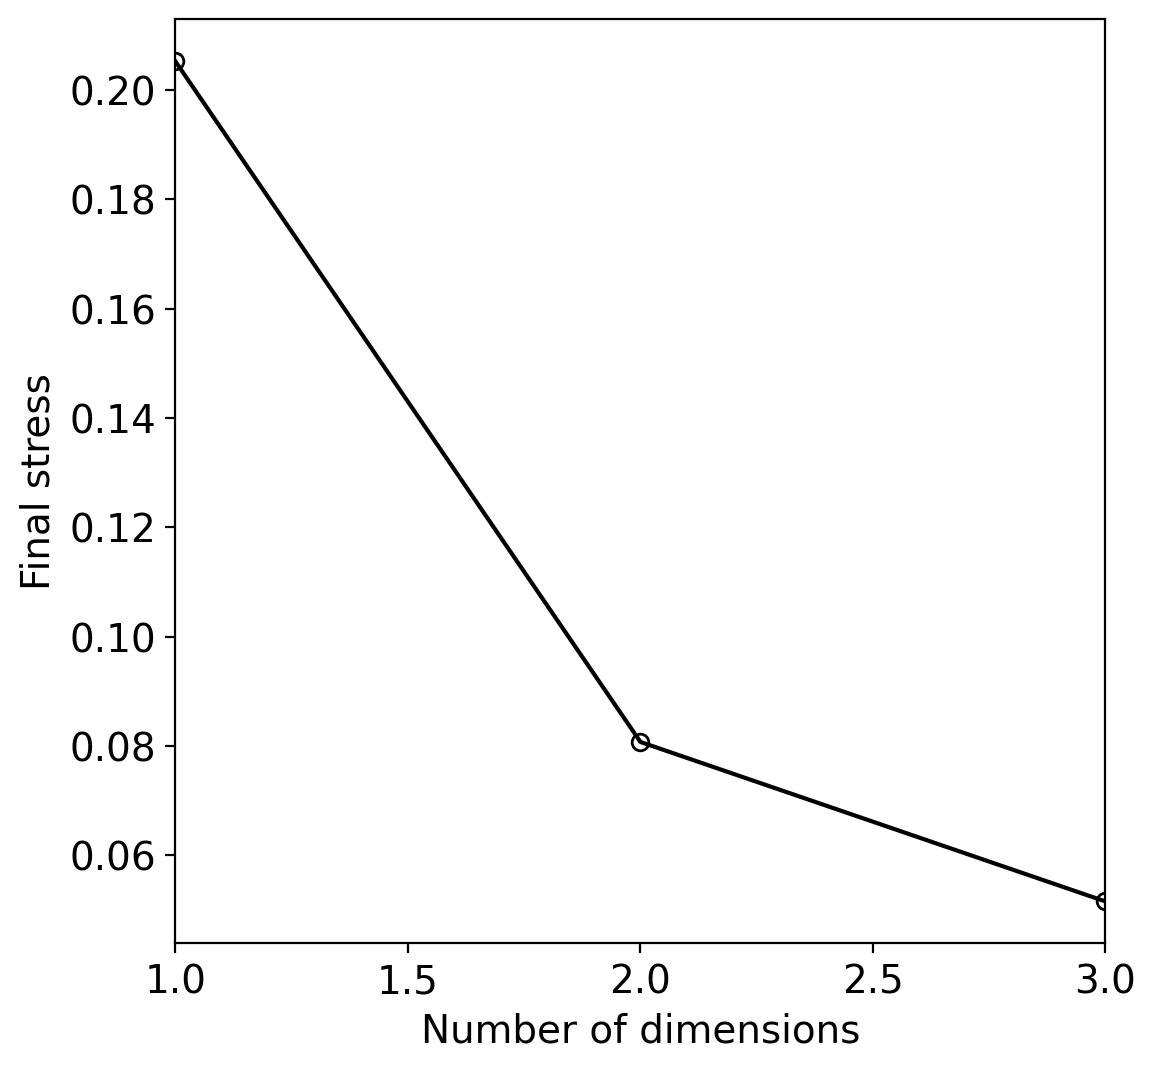

In [21]:
model.stressPlot(figsize=(6,6), savePlot=False, fileName='stressPlot.pdf')

A Shepard plot compares x-y distance on the MDS plot against the dissimilarity metric. Ideally, sample pairs that are far apart on the MDS plot (large distance) will also be the most dissimilar, and visa versa. The amount of scatter gives a sense of the stress value - a lot of scatter means that there's a lot of variance in how well distance on the MDS plot characterizes sample dissimilarity.

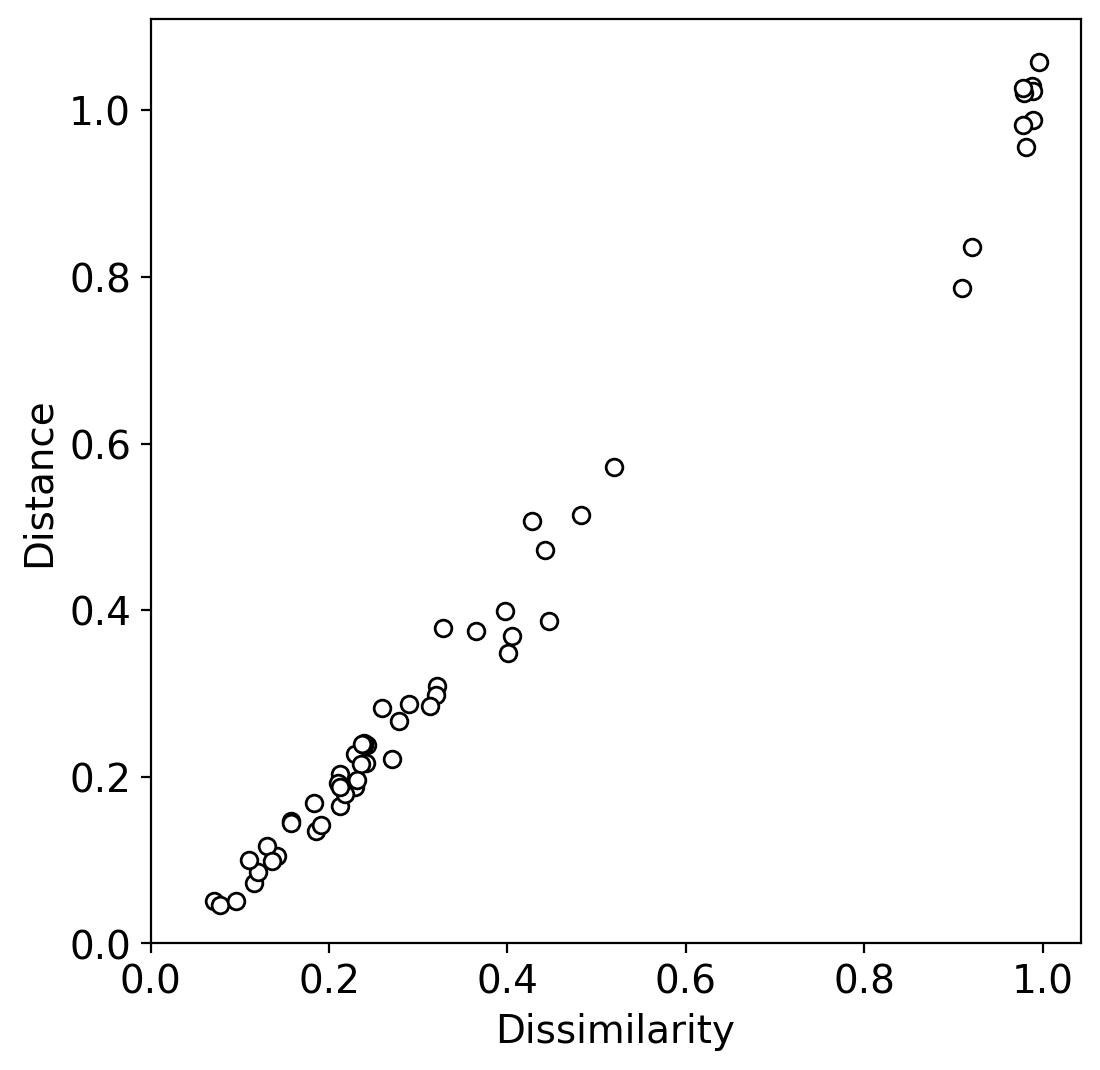

In [22]:
model.shepardPlot(figsize=(6,6), savePlot=False, fileName='shepardPlot.pdf', plotOneToOneLine=False)

The MDS plot is a depiction of sample similarity and dissimilarity (refer to Vermeesch, 2013: Chemical Geology for a more complete description).

Final stress:  0.0807156689125653


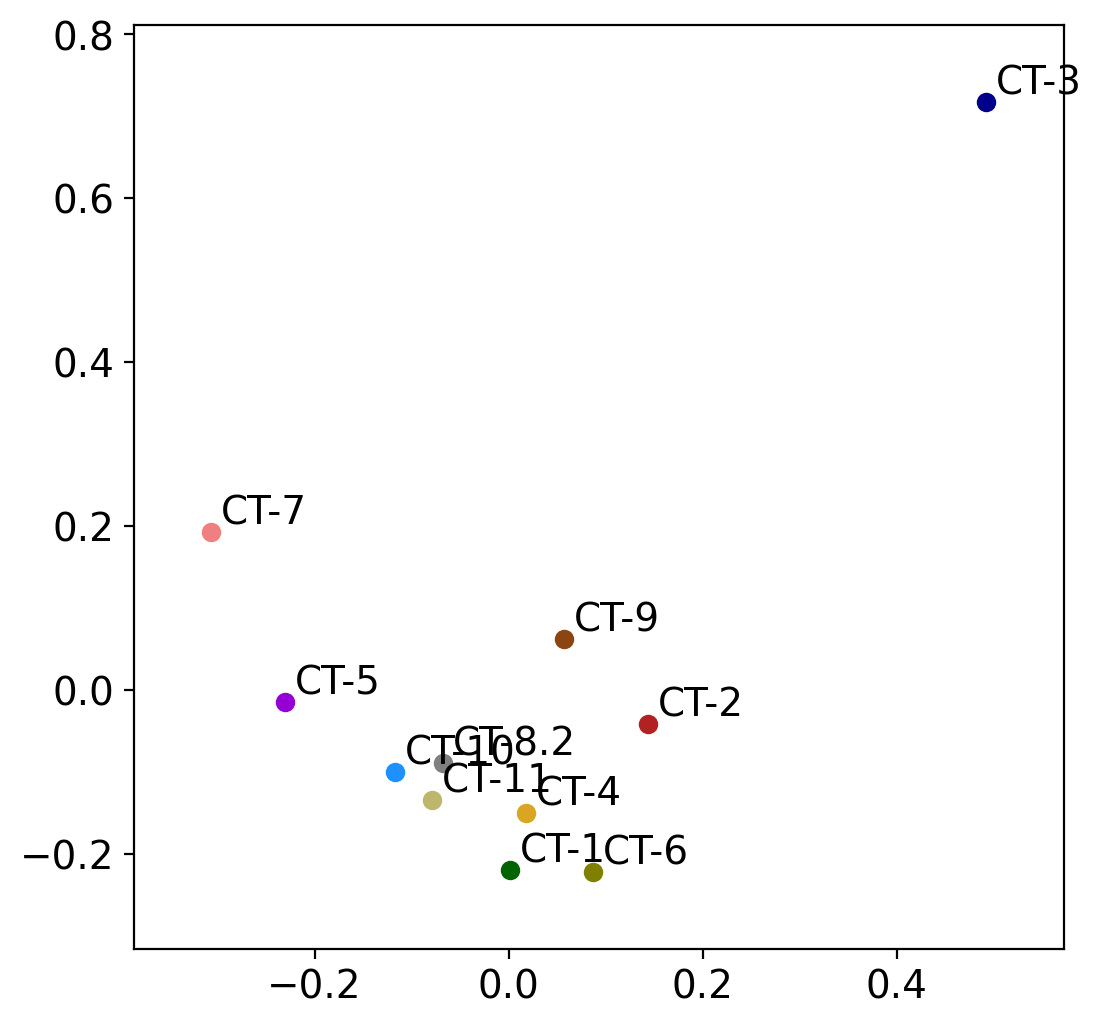

In [23]:
model.MDSplot(figsize=(6,6), savePlot=False, fileName='MDSplot.pdf', plotLabels=True, equalAspect=False, 
              stressType='sklearn')

Note that individual samples can be colored accoring to a categorical variable (column name in the 'Samples' table)

### No units associated with the detrital data

In [24]:
#model.MDSplot(figsize=(6,6), savePlot=False, fileName='MDSplot.pdf', plotLabels=True, colorBy='Unit', 
 #             df=main_byid_df, equalAspect=False, stressType='sklearn')

Samples can also be plotted as pie diagrams where bins correspond to different age categories

Final stress:  0.0807156689125653


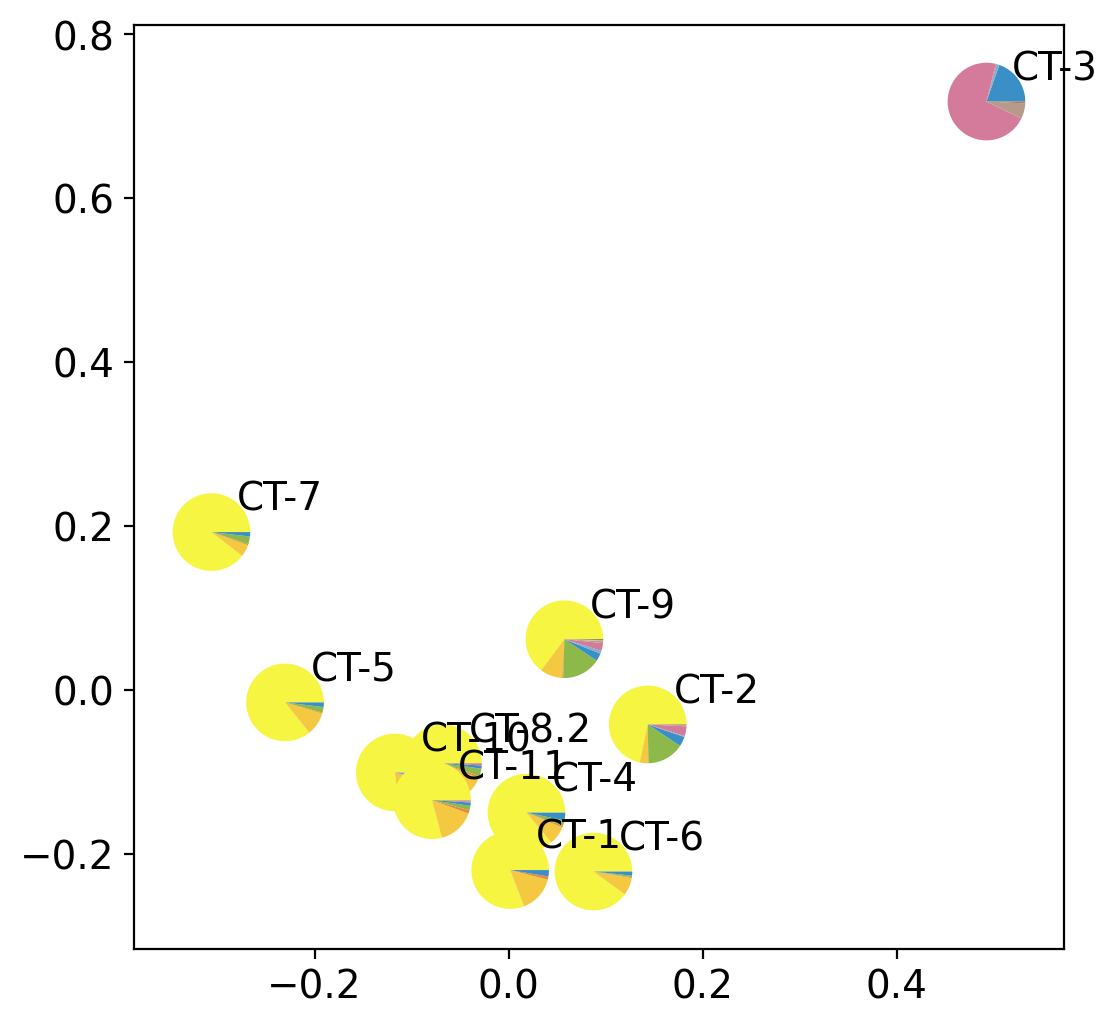

In [25]:
# Alternative way of specifying age bins
agebins = [[0,15],[15,30],[32,74],[82,119],[140,190],[200,252],[252,284],[284,320],[320,385],[385,440],[440,505],[505,550]]
agebinsc = [
    '#f5f542',  # yellow-green 
    '#f5c842',  # golden yellow 
    '#e8893a',  # muted orange 
    '#8db84a',  # muted yellow-green 
    '#3a8fc7',  # muted blue 
    '#7ab0d4',  # mid blue 
    '#d47a6e',  # muted salmon 
    '#d47a9a',  # muted pink 
    '#b89a8a',  # warm grey-brown 
    '#c8b89a',  # warm tan 
    '#a08060',  # mid tan 
    '#6e7840',  # muted olive 
]

model.MDSplot(figsize=(6,6), savePlot=False, fileName='MDSplot.pdf', plotLabels=True, 
              plotPie=True, pieType='Age', pieSize=0.04, agebins=agebins, agebinsc=agebinsc, equalAspect=False)

## Export sample comparison matrices as a CSV file
Creates matricies of sample comparisons using a number of different metrics (see Saylor and Sundell, 2016). Similiarity, likness, Kolgomorov-Smirnov statistic (Dmax and p-value), Kuiper statistic (Vmax and p-value), and cross-correlation of relative probability density functions. Similiarty, likeness, and cross-correlation values are computed based on either the probability density plot (PDP) or kernal density estimation (KDE).

In [26]:
sampleList = ['CT-1','CT-2','CT-3','CT-4','CT-5','CT-6','CT-7','CT-8.2','CT-9','CT-10','CT-11']

ages, errors, numGrains, labels = dFunc.sampleToData(sampleList, main_byid_df, sigma = '2sigma');

In [28]:
calculateSimilarity = True
calculateLikeness = True
calculateKS = True
calculateKuiper = True
calculateR2 = True
calculateW2 = True
fileName = 'interSampleComparisonKDE.csv'

# Specify what type of relative distribution to compare for similarity, likeness, and cross-correlation calculations
distType = 'KDE' # Options are 'PDP' or 'KDE'
bw = 2 # Specify the bandwidth for the KDE distribution. Options are 'optimizedFixed','optimizedVariable', or a number (Ma)

#dFunc.calcComparisonCSV(ages, errors, numGrains, labels, sampleList, calculateSimilarity, calculateLikeness,
#                        calculateKS, calculateKuiper, calculateR2, calculateW2, fileName, distType, bw)
dFunc.calcComparisonCSV(
    ages=ages, 
    errors=errors, 
    numGrains=numGrains, 
    labels=labels, 
    sampleList=sampleList, 
    calculateSimilarity=calculateSimilarity, 
    calculateLikeness=calculateLikeness,
    calculateKS=calculateKS, 
    calculateKuiper=calculateKuiper, 
    calculateR2=calculateR2, 
    calculateW2=calculateW2, 
    fileName=fileName, 
    distType=distType, 
    bw=bw)

## Export detrital age distributions as a CSV file
Creates a CSV file with raw age distribution data. Distribution types supported are cumulative density functions (CDFs), probability density plots (PDPs), and kernal density estimations (KDEs).

In [29]:
import numpy as np
# ages is a list of arrays, one per sample - flatten to check across all samples
all_ages = np.concatenate(ages)
print(np.nanmax(all_ages))

2012.8


In [31]:
# Specify export options
exportType = 'CDF' # Options: 'CDF', 'PDP' or 'KDE'
cumulative = False # Only applies if exportType = 'PDP' or 'KDE'

# Specify the age range that you want to export
x1 = 0
x2 = 2100
# Specify the KDE bandwidth
bw = 2 # Options are 'optimizedFixed', 'optimizedVariable', or a number (bandwidth in Ma)
# Specify the interval over which distributions are calculated
xdif = 1
# Require distributions to sum to 1
normalize = True

# Specify file name to save
fileName = 'Dist_to_CSV.csv'

dFunc.exportDist(ages, errors, labels, exportType, cumulative, x1, x2, xdif, bw, fileName, normalize)

## Export ages and errors in tabular format as a CSV file
Creates a CSV file with sample or sample group ages and 1 sigma errors reported in the two-column format that is used by other plotting and analysis software (e.g., DZstats (Saylor and Sundel, 2016) and Arizona LaserChron Center in-house excel macros).

In [33]:
# Specify file name to save

fileName = 'AgeError_toCSV.csv'

dFunc.agesErrorsCSV(ages, errors, sampleList, fileName)

# Critical-D test

In [34]:
# =============================================================================
# Phase 1 — Parent-comparison table for the two mixing systems
# Reads detritalPy's interSampleComparison.csv and reports the two parent pairs
# in a hypothesis-test format (Amidon et al. 2005, Basin Res., Tables 6-7):
#   Dmax, critical-D at this n, Kuiper Vmax, KS p-value  -> distinguishable?
# Descriptive metrics (similarity/likeness/cross-corr) are reported SEPARATELY
# and labelled as non-tests, per Reviewer 1 (Sharman) line 445-446.
# =============================================================================
import pandas as pd
import numpy as np
import csv

# --- 1. Sample grain counts (n) from the loaded data, needed for critical-D ---
# Pulled live so D_crit can never drift out of sync with the actual samples.
n = {s: numGrains[sampleList.index(s)] for s in ['CT-5', 'CT-6', 'CT-8.2', 'CT-3']}
# Hardcoded here for clarity; REPLACE with your live counts to stay in sync.
#n = {'CT-5': 259, 'CT-6': 299, 'CT-8.2': 222, 'CT-3': 267}

# --- 2. The two parent pairs that feed the mixing models ---
pairs = [('CT-5', 'CT-6'),      # below-confluence system parents
         ('CT-8.2', 'CT-3')]    # outlet system parents

# --- 3. Parse the stacked-matrix comparison CSV into {metric: {A: {B: value}}} ---
# detritalPy writes several labelled matrices separated by blank rows.
def load_comparison(path):
    rows = list(csv.reader(open(path)))
    blocks, name, header = {}, None, None
    for r in rows:
        cells = [c.strip() for c in r]
        if not any(cells):                      # blank separator row
            continue
        if cells[0] == 'Label':                 # header row listing sample names
            header = cells
            blocks[name] = {'cols': header[2:], 'data': {}}
            continue
        # a lone non-empty first cell = the name of the next metric block
        if len(cells) == 1 or (cells[0] and all(x == '' for x in cells[1:])):
            name = cells[0]
            continue
        if header is not None and name in blocks:  # a data row of the current block
            blocks[name]['data'][cells[0]] = dict(zip(blocks[name]['cols'], cells[2:]))
    return blocks

blocks = load_comparison(os.path.join(DETRITAL_RES_DIR, 'interSampleComparisonKDE.csv'))

def get(metric, a, b):
    """Fetch metric value for pair (a,b), matrix may store either orientation."""
    d = blocks.get(metric, {}).get('data', {})
    if a in d and b in d.get(a, {}) and d[a][b] != '':
        return float(d[a][b])
    if b in d and a in d.get(b, {}) and d[b][a] != '':
        return float(d[b][a])
    return np.nan

# --- 4. Two-sample KS critical-D at alpha=0.05 (Amidon Table 7 style) ---
# D_crit = c(alpha) * sqrt((n1+n2)/(n1*n2)),  c(0.05)=1.36
def d_crit(n1, n2, alpha=0.05):
    c = {0.10: 1.22, 0.05: 1.36, 0.01: 1.63}[alpha]
    return c * np.sqrt((n1 + n2) / (n1 * n2))

# --- 5. Build the HYPOTHESIS-TEST table (KS + Kuiper) ---
test_rows = []
for a, b in pairs:
    dmax = get('Kolgomorov-Smirnov Dmax', a, b)      # note detritalPy's spelling
    pval = get('Kolgomorov-Smirnov p-value', a, b)
    vmax = get('Kuiper Vmax', a, b)
    dc   = d_crit(n[a], n[b], 0.05)
    test_rows.append({
        'Pair': f'{a} vs {b}',
        'n1': n[a], 'n2': n[b],
        'KS Dmax': round(dmax, 3),
        'D_crit(0.05)': round(dc, 3),
        'KS p-value': f'{pval:.2e}',
        'Kuiper Vmax': round(vmax, 3),
        'Distinguishable?': 'YES' if dmax > dc else 'no',
    })
test_df = pd.DataFrame(test_rows)

# --- 6. Build the DESCRIPTIVE table (NOT hypothesis tests) ---
desc_rows = []
for a, b in pairs:
    desc_rows.append({
        'Pair': f'{a} vs {b}',
        'Similarity':        round(get('Similarity', a, b), 3),
        'Likeness':          round(get('Likeness', a, b), 3),
        'Cross-correlation': round(get('Cross-correlation of kernal density estimation', a, b), 1),
    })
desc_df = pd.DataFrame(desc_rows)

# --- 7. Report ---
print('HYPOTHESIS TESTS (KS, Kuiper) — support "distinguishable/indistinguishable" claims')
print(test_df.to_string(index=False))
print('\nDESCRIPTIVE METRICS — similarity indices, NOT statistical tests (no null distribution)')
print('   report alongside, but do NOT use to claim samples are "(in)distinguishable"')
print(desc_df.to_string(index=False))

HYPOTHESIS TESTS (KS, Kuiper) — support "distinguishable/indistinguishable" claims
          Pair  n1  n2  KS Dmax  D_crit(0.05) KS p-value  Kuiper Vmax Distinguishable?
  CT-5 vs CT-6 259 299    0.335         0.115   2.68e-14        0.328              YES
CT-8.2 vs CT-3 222 267    0.978         0.124  5.96e-134        0.978              YES

DESCRIPTIVE METRICS — similarity indices, NOT statistical tests (no null distribution)
   report alongside, but do NOT use to claim samples are "(in)distinguishable"
          Pair  Similarity  Likeness  Cross-correlation
  CT-5 vs CT-6       0.919     0.806               51.3
CT-8.2 vs CT-3       0.106     0.023              274.7
